---
numbering: false
---

# 2.1: Lines in ℝ²

In [1]:
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import sys

_notes_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'myst.yml').exists())
if str(_notes_root) not in sys.path:
    sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly

BLUE, ORANGE, PINK = '#3d81f6', 'orange', '#d81a60'
ANNOTATION_SIZE = 24


def base2(xrange=(-5, 6), yrange=(-5, 5), width=700, height=580, tick=1):
    fig = style_plotly(go.Figure(), renderer='png')
    fig.update_layout(width=width, height=height, showlegend=False,
                      font=dict(size=17), margin=dict(l=55, r=30, t=30, b=50))
    fig.update_xaxes(title='x', range=xrange, dtick=tick, zeroline=True, zerolinewidth=1.5,
                     constrain='domain', scaleanchor='y', scaleratio=1)
    fig.update_yaxes(title='y', range=yrange, dtick=tick, zeroline=True, zerolinewidth=1.5,
                     constrain='domain')
    return fig


def line2(fig, start, end, color=BLUE, dash='solid', width=2):
    fig.add_trace(go.Scatter(x=[start[0], end[0]], y=[start[1], end[1]], mode='lines',
                            line=dict(color=color, width=width, dash=dash),
                            hoverinfo='skip', showlegend=False))


def label2(fig, xy, label, dx=0, dy=0, color='black'):
    # MathJax needs its own size command when exporting math labels to PNG.
    if label.startswith('$') and label.endswith('$'):
        label = r'$\Large ' + label[1:]
    fig.add_annotation(x=float(xy[0])+dx, y=float(xy[1])+dy, text=label, showarrow=False,
                       font=dict(family='Palatino', color=color, size=ANNOTATION_SIZE))


def point2(fig, xy, label=None, dx=0.35, dy=0.35):
    fig.add_trace(go.Scatter(x=[xy[0]], y=[xy[1]], mode='markers',
                            marker=dict(color='black', size=7), hoverinfo='skip'))
    if label: label2(fig, xy, '$' + label.replace('−', '-') + '$', dx, dy)


def vec2(fig, end, label=None, color=BLUE, start=(0, 0), dx=0.3, dy=0.3, width=4):
    # Match Chapter 1.4: a colored shaft, arrowhead, and midpoint math label.
    line2(fig, start, end, color=color, width=width)
    fig.add_annotation(x=float(end[0]), y=float(end[1]), ax=float(start[0]), ay=float(start[1]),
                       xref='x', yref='y', axref='x', ayref='y', showarrow=True,
                       text='', arrowhead=3, arrowsize=1.2, arrowwidth=3, arrowcolor=color)
    if label:
        midpoint = (np.asarray(start, dtype=float) + np.asarray(end, dtype=float)) / 2
        label2(fig, midpoint, label, dx, dy, color=color)


def square2(fig, corner, along, perp, size=0.3):
    corner=np.asarray(corner,dtype=float)
    u=np.asarray(along,dtype=float); u=u/np.linalg.norm(u)*size
    v=np.asarray(perp,dtype=float); v=v/np.linalg.norm(v)*size
    line2(fig,corner+u,corner+u+v,'gray',width=1.5)
    line2(fig,corner+v,corner+u+v,'gray',width=1.5)


def base3():
    fig=style_plotly(go.Figure(),renderer='plotly_mimetype')
    axis=dict(range=[-6,7],dtick=2,showbackground=True,showspikes=False)
    fig.update_layout(width=760,height=620,showlegend=False,font=dict(size=16),
                      margin=dict(l=0,r=0,t=15,b=0),
                      scene=dict(xaxis=dict(title='x',**axis),yaxis=dict(title='y',**axis),
                                 zaxis=dict(title='z',**axis),aspectmode='cube',
                                 camera=dict(eye=dict(x=1.6,y=-2.1,z=1.3))))
    for direction in np.eye(3):
        line3(fig,-6*direction,7*direction,'#9ca3af',width=2)
    return fig


def line3(fig,start,end,color=BLUE,width=5,dash='solid'):
    fig.add_trace(go.Scatter3d(x=[start[0],end[0]],y=[start[1],end[1]],z=[start[2],end[2]],
                              mode='lines',line=dict(color=color,width=width,dash=dash),
                              hoverinfo='skip',showlegend=False))


def vec3(fig,end,label,color=BLUE,start=(0,0,0),offset=(0.25,0.25,0.35)):
    start,end=np.asarray(start,float),np.asarray(end,float)
    direction=(end-start)/np.linalg.norm(end-start)
    line3(fig,start,end-0.15*direction,color,width=7)
    fig.add_trace(go.Cone(x=[end[0]],y=[end[1]],z=[end[2]],u=[direction[0]],v=[direction[1]],w=[direction[2]],
                         anchor='tip',sizemode='absolute',sizeref=0.45,colorscale=[[0,color],[1,color]],
                         showscale=False,hoverinfo='skip'))
    pos=end+offset
    fig.add_trace(go.Scatter3d(x=[pos[0]],y=[pos[1]],z=[pos[2]],mode='text',text=[label],
                              textfont=dict(color='black',size=16),hoverinfo='skip'))


def plane3(fig,normal,color=BLUE,opacity=0.24):
    # Solve n_x*x + n_y*y + n_z*z = 0 for y on a rectangular x,z mesh.
    x,z=np.meshgrid(np.linspace(-5,6,2),np.linspace(-5,6,2))
    n=np.asarray(normal,float)
    y=-(n[0]*x+n[2]*z)/n[1]
    fig.add_trace(go.Surface(x=x.tolist(),y=y.tolist(),z=z.tolist(),
                            colorscale=[[0,color],[1,color]],opacity=opacity,
                            showscale=False,hoverinfo='skip'))
    corners=np.array([[x[0,0],y[0,0],z[0,0]],[x[0,1],y[0,1],z[0,1]],
                      [x[1,1],y[1,1],z[1,1]],[x[1,0],y[1,0],z[1,0]]])
    for i in range(4): line3(fig,corners[i],corners[(i+1)%4],color,width=2)


In [Chapter 1.4](../ch01/01-04.ipynb), we drew the vector

$$
\vec v=\begin{bmatrix}3\\-1\end{bmatrix}
$$

along with $3\vec v$ and $-\tfrac12\vec v$. When drawn from the origin, all three arrows lie on the **same line**.

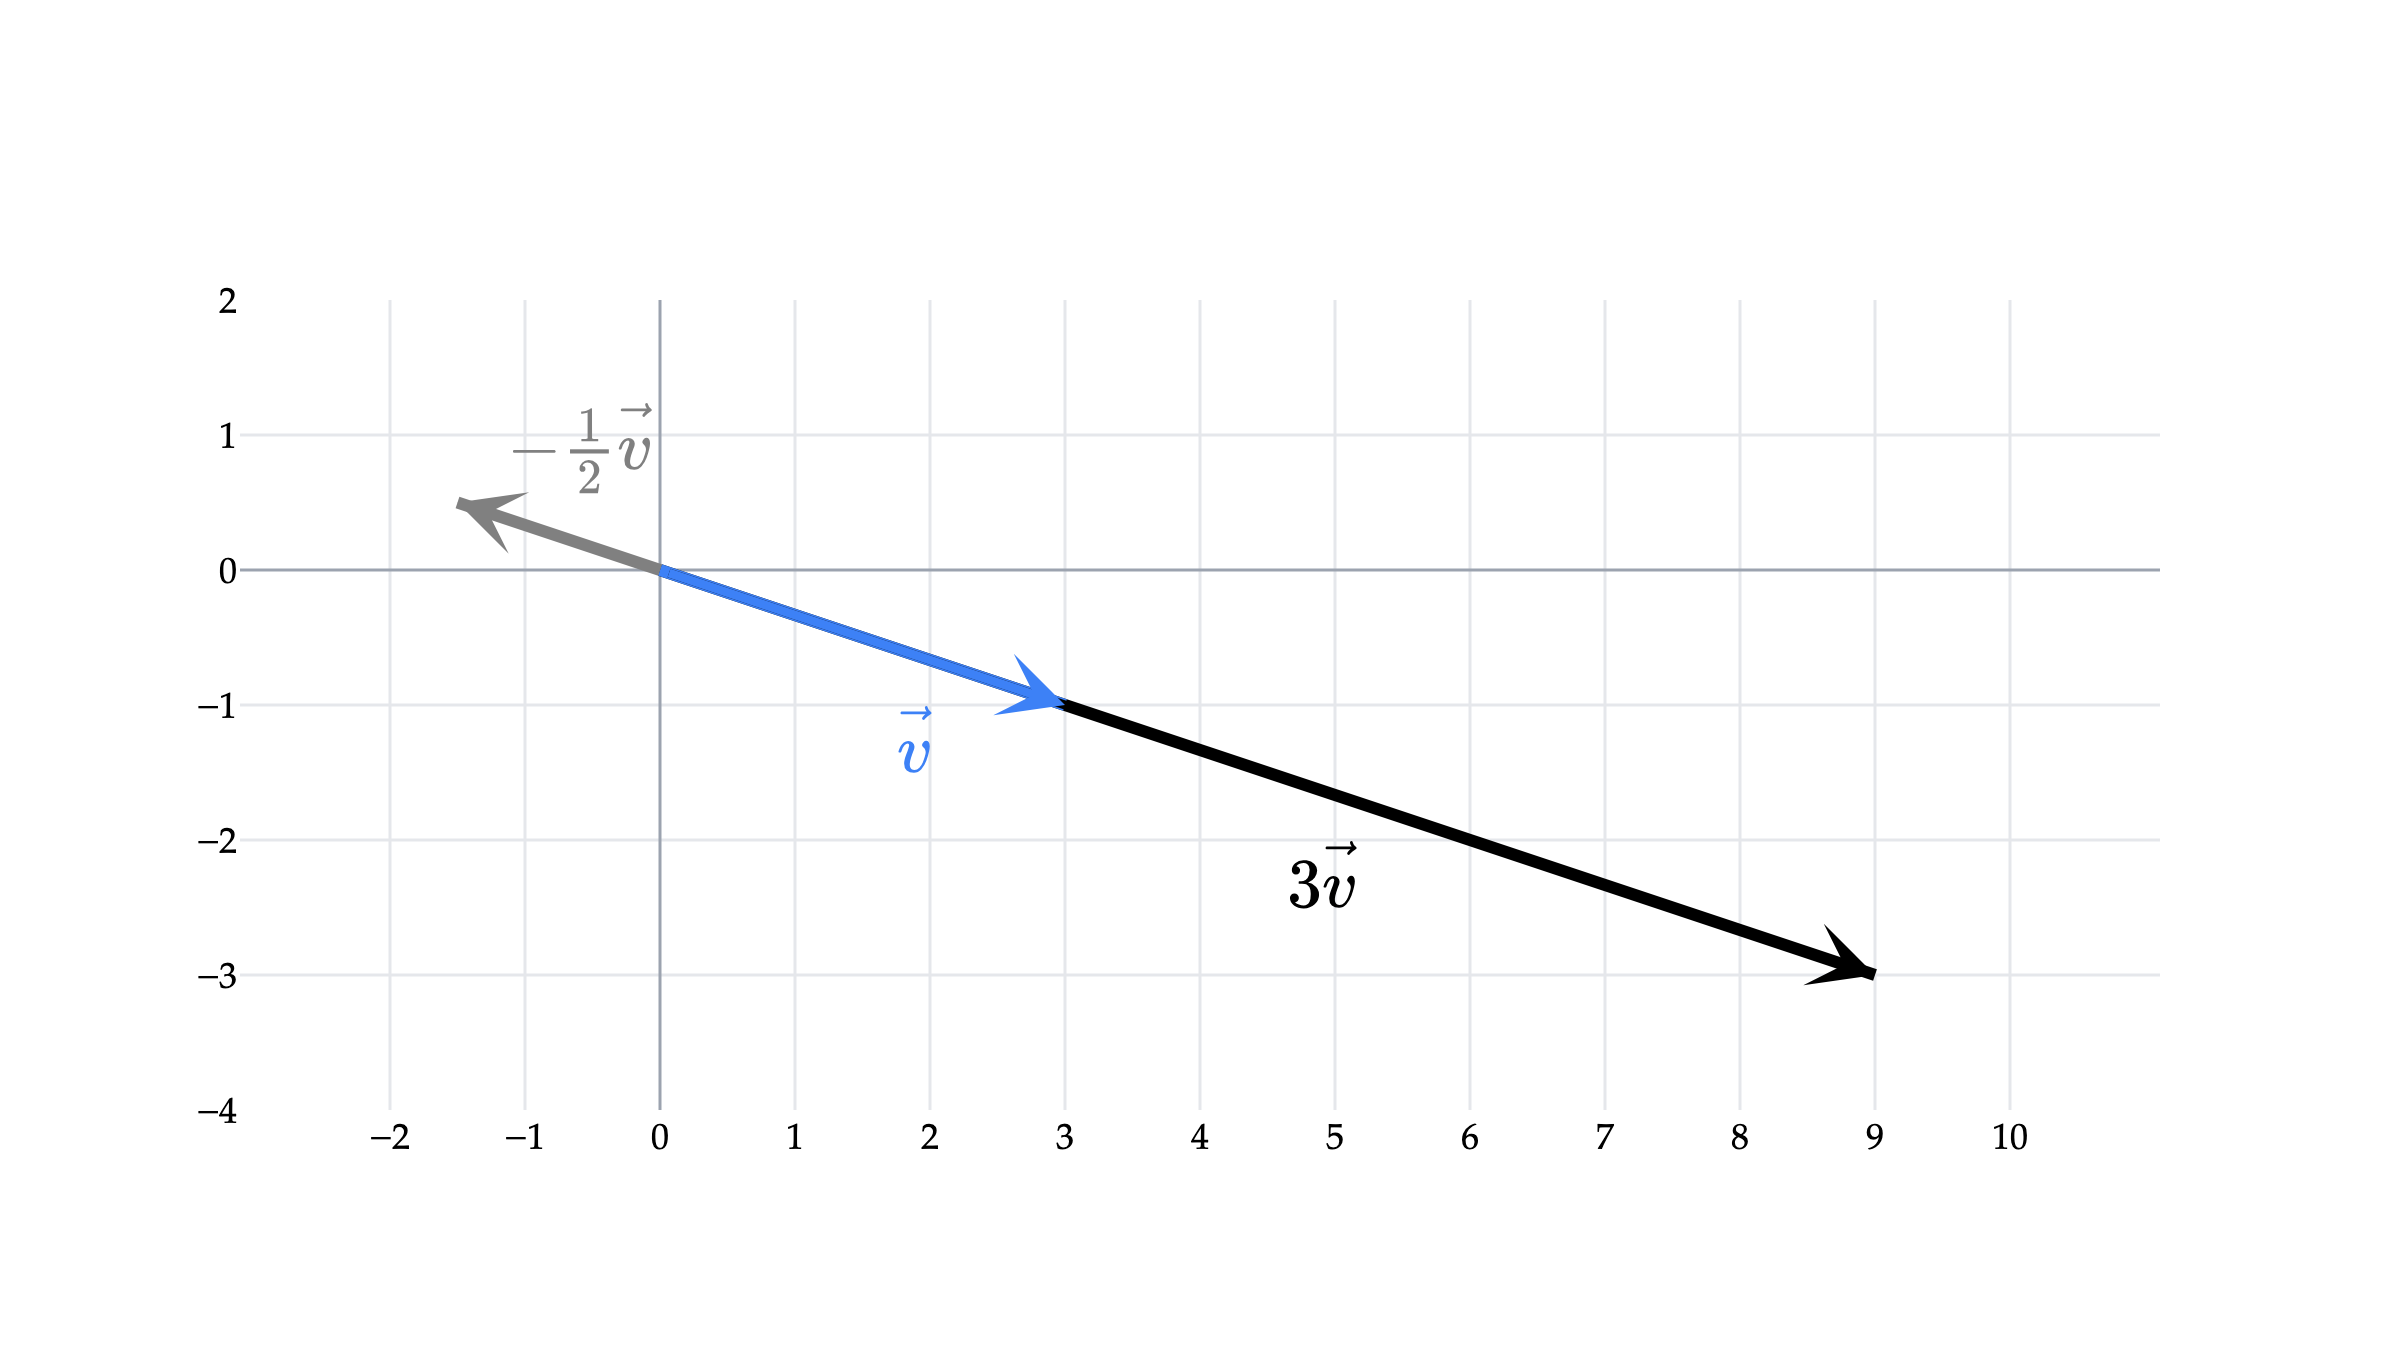

In [2]:
# Recreate Chapter 1.4's plot with the larger annotation size used in this section.
from IPython.display import Image, display

fig = style_plotly(go.Figure(), renderer='png')
vdeltay = 0.7
# Draw 3v first so that v remains visible on top of it.
for end, color, label in [
    ((9, -3), 'black', r'$3\vec{v}$'),
    ((3, -1), BLUE, r'$\vec{v}$'),
    ((-1.5, 0.5), 'gray', r'$-\frac{1}{2}\vec{v}$'),
]:
    line2(fig, (0, 0), end, color=color, width=4)
    fig.add_annotation(
        x=end[0], y=end[1], ax=0, ay=0,
        xref='x', yref='y', axref='x', ayref='y',
        showarrow=True, arrowhead=3, arrowsize=1.2, arrowwidth=3,
        arrowcolor=color,
    )
    label2(fig, np.asarray(end) / 2, label, dx=0.4, dy=-vdeltay, color=color)

fig.update_layout(width=800, height=450, yaxis_scaleanchor='x')
fig.update_xaxes(range=[-2, 10], tickvals=np.arange(-2, 11))
fig.update_yaxes(range=[-4, 2], tickvals=np.arange(-4, 3))
fig.layout.annotations[5].x -= 0.25
fig.layout.annotations[5].y += 2 * vdeltay

image_path = _notes_root / 'ch02/imgs/scalar-multiplication-from-1-4.png'
fig.write_image(str(image_path), scale=3)
display(Image(filename=str(image_path)))

```{figure} #plot-21-scalar-multiples
:label: fig-21-scalar-multiples
:class: course-caption
:alt: Three scalar multiples of a vector lie on one line through the origin.

$\vec v=\begin{bmatrix}3\\-1\end{bmatrix}$ and its scalar multiples lie on the same line.
```

What if we drew **every** scalar multiple of $\vec v$? Positive multiples extend along one direction, negative multiples extend along the opposite direction, and $0\vec v$ gives the origin. Together, they fill the entire line!

We'll call this collection the **span** of $\vec v$ and connect it to a familiar line equation. Then we'll use orthogonality from [Chapter 1.6](../ch01/01-06.ipynb) to describe the same line using a perpendicular vector.

---

## Homogeneous and nonhomogeneous equations

A line in $\mathbb R^2$ has an equation $ax+by=c$, where $a$ and $b$ are not both zero. Let's start with

$$\ell:\quad 3x-4y=0.$$

This line passes through the origin: substituting $(0,0)$ gives $3(0)-4(0)=0$.

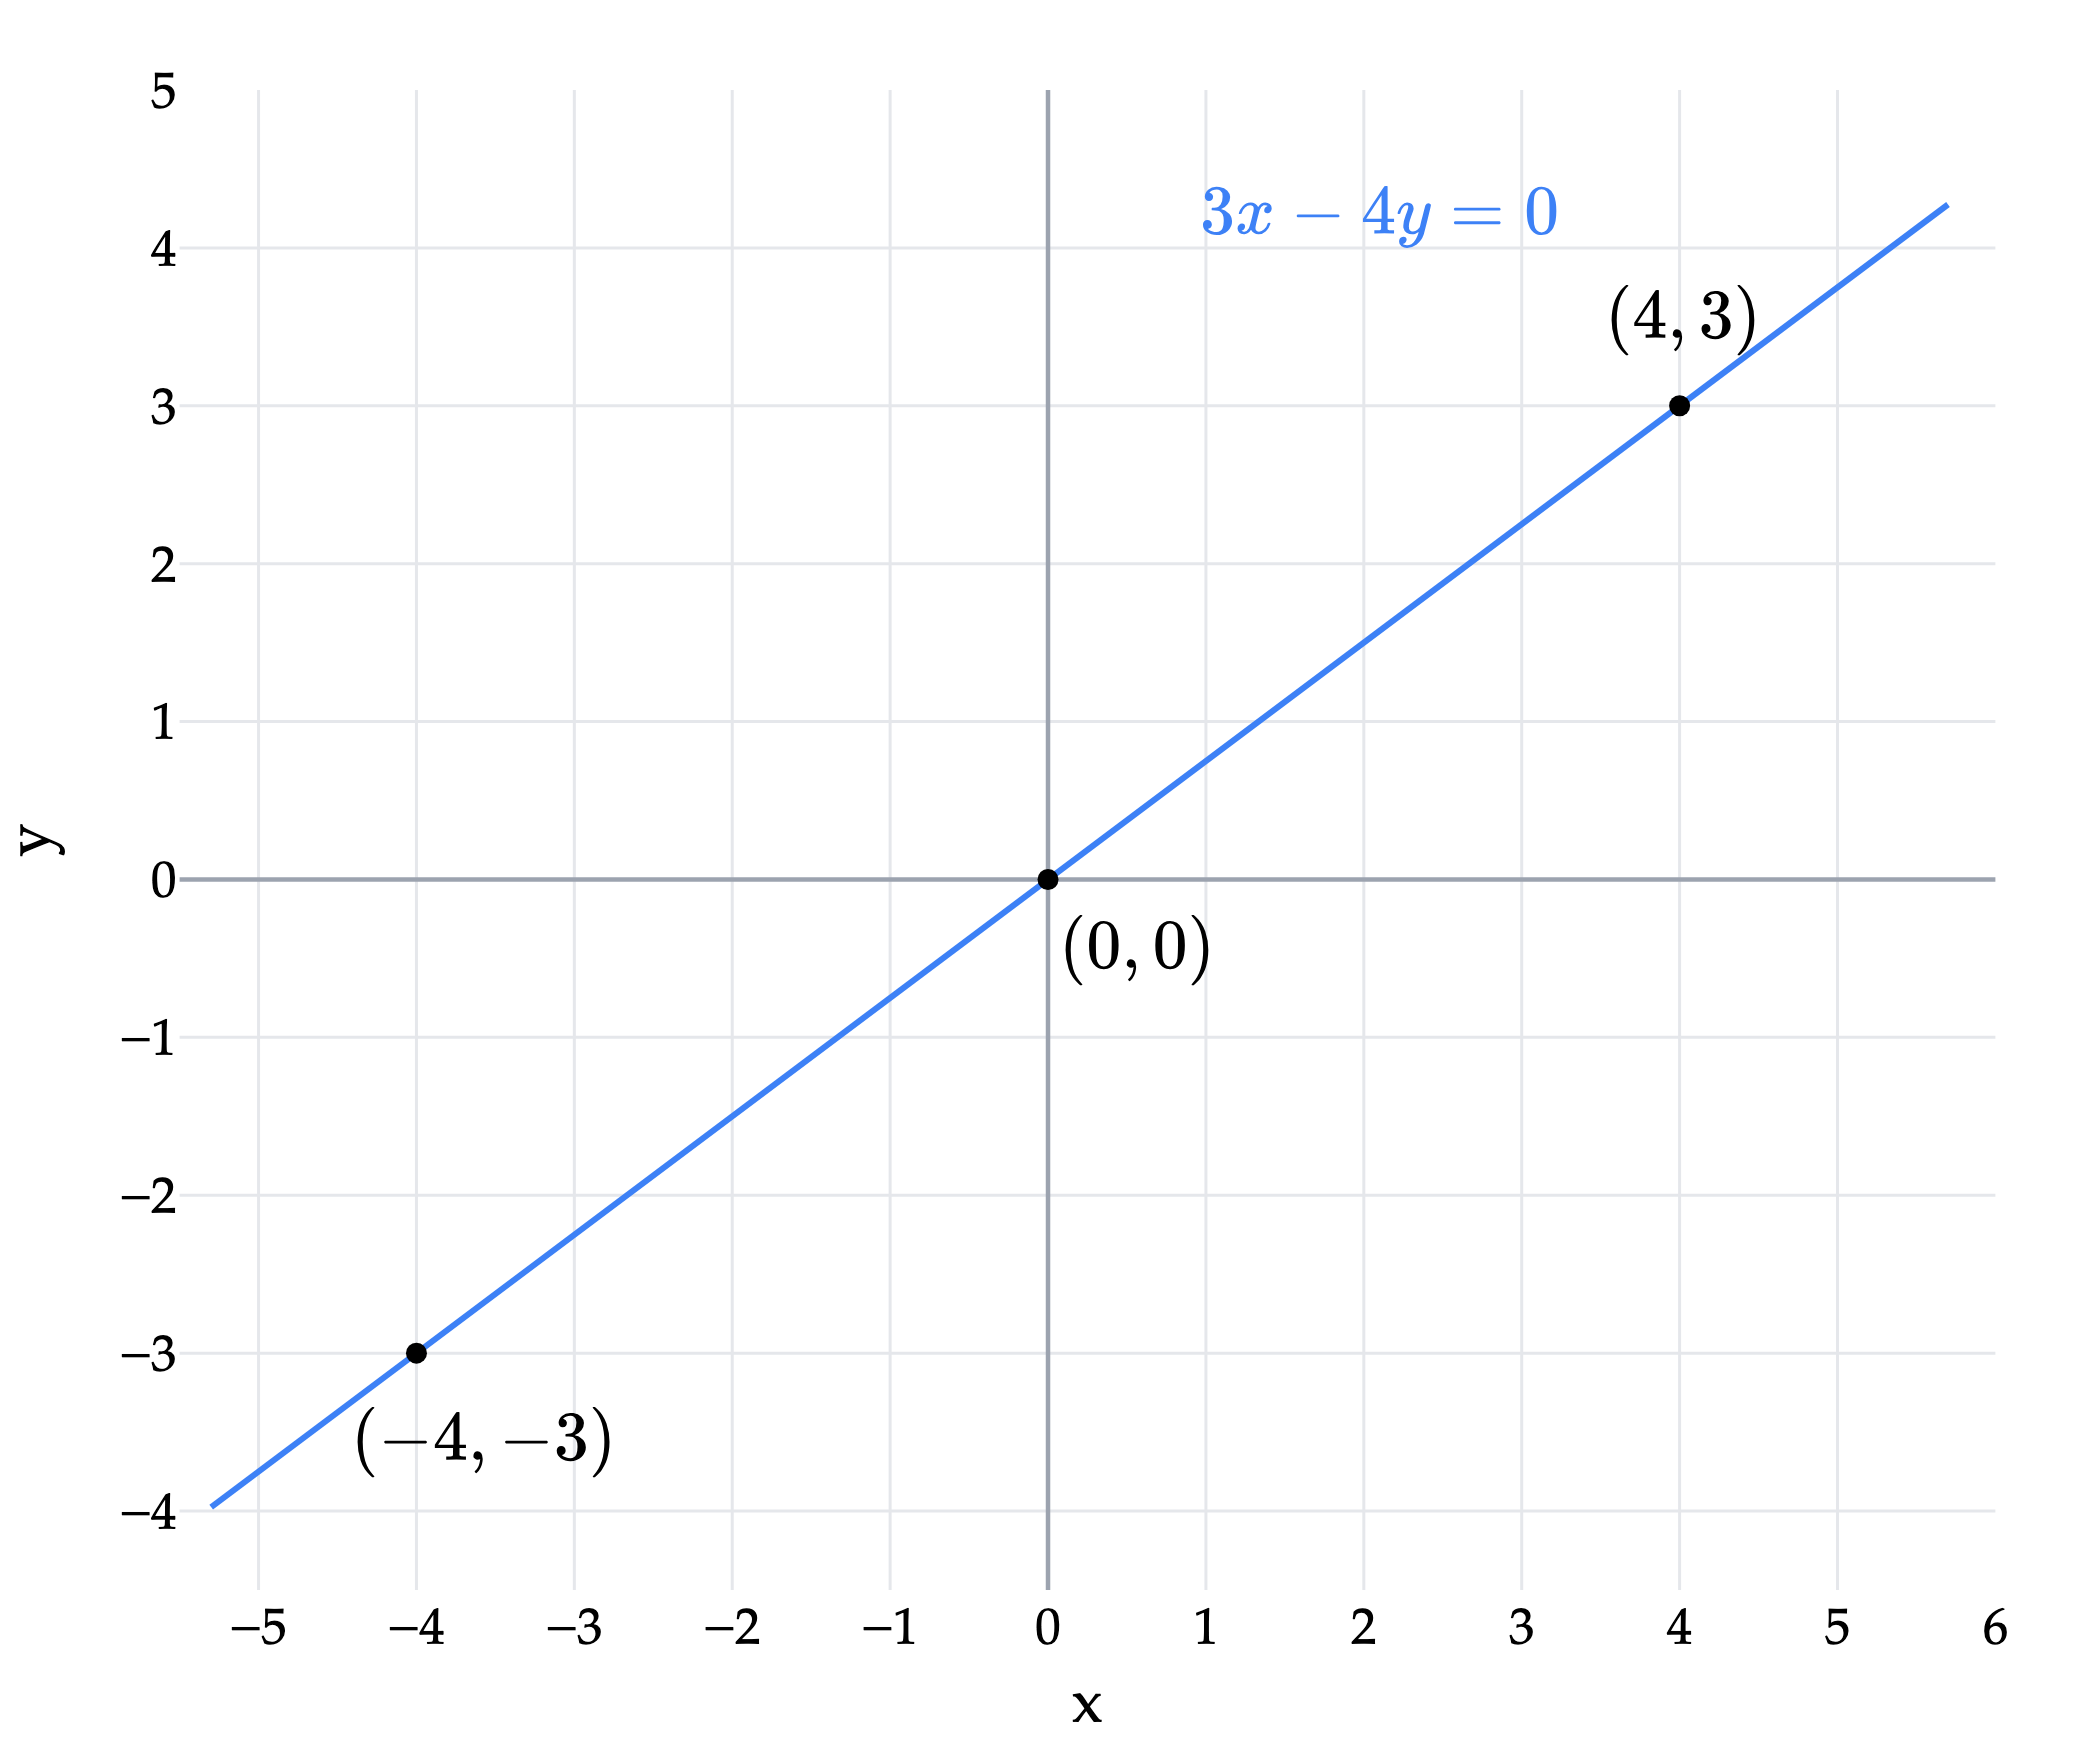

In [3]:
fig=base2((-5.5,6),(-4.5,5))
line2(fig,(-5.3,-3.975),(5.7,4.275))
for xy,dx,dy in [((0,0),0.55,-0.45),((4,3),0,0.55),((-4,-3),0.4,-0.55)]:
    point2(fig,xy,str(xy),dx,dy)
label2(fig,(2.1,4.2),r'$3x-4y=0$',color=BLUE)
fig.show(scale=3)

```{figure} #plot-21-homogeneous-line
:label: fig-21-homogeneous-line
:class: course-caption
:alt: The line 3x minus 4y equals zero through the points (0, 0), (4, 3), and (-4, -3).

The line $3x-4y=0$ passes through the origin.
```

What happens if we change the right-hand side from $0$ to $7$? The origin no longer satisfies the equation, since $3(0)-4(0)\ne7$. Instead, $3x-4y=7$ describes a parallel line.

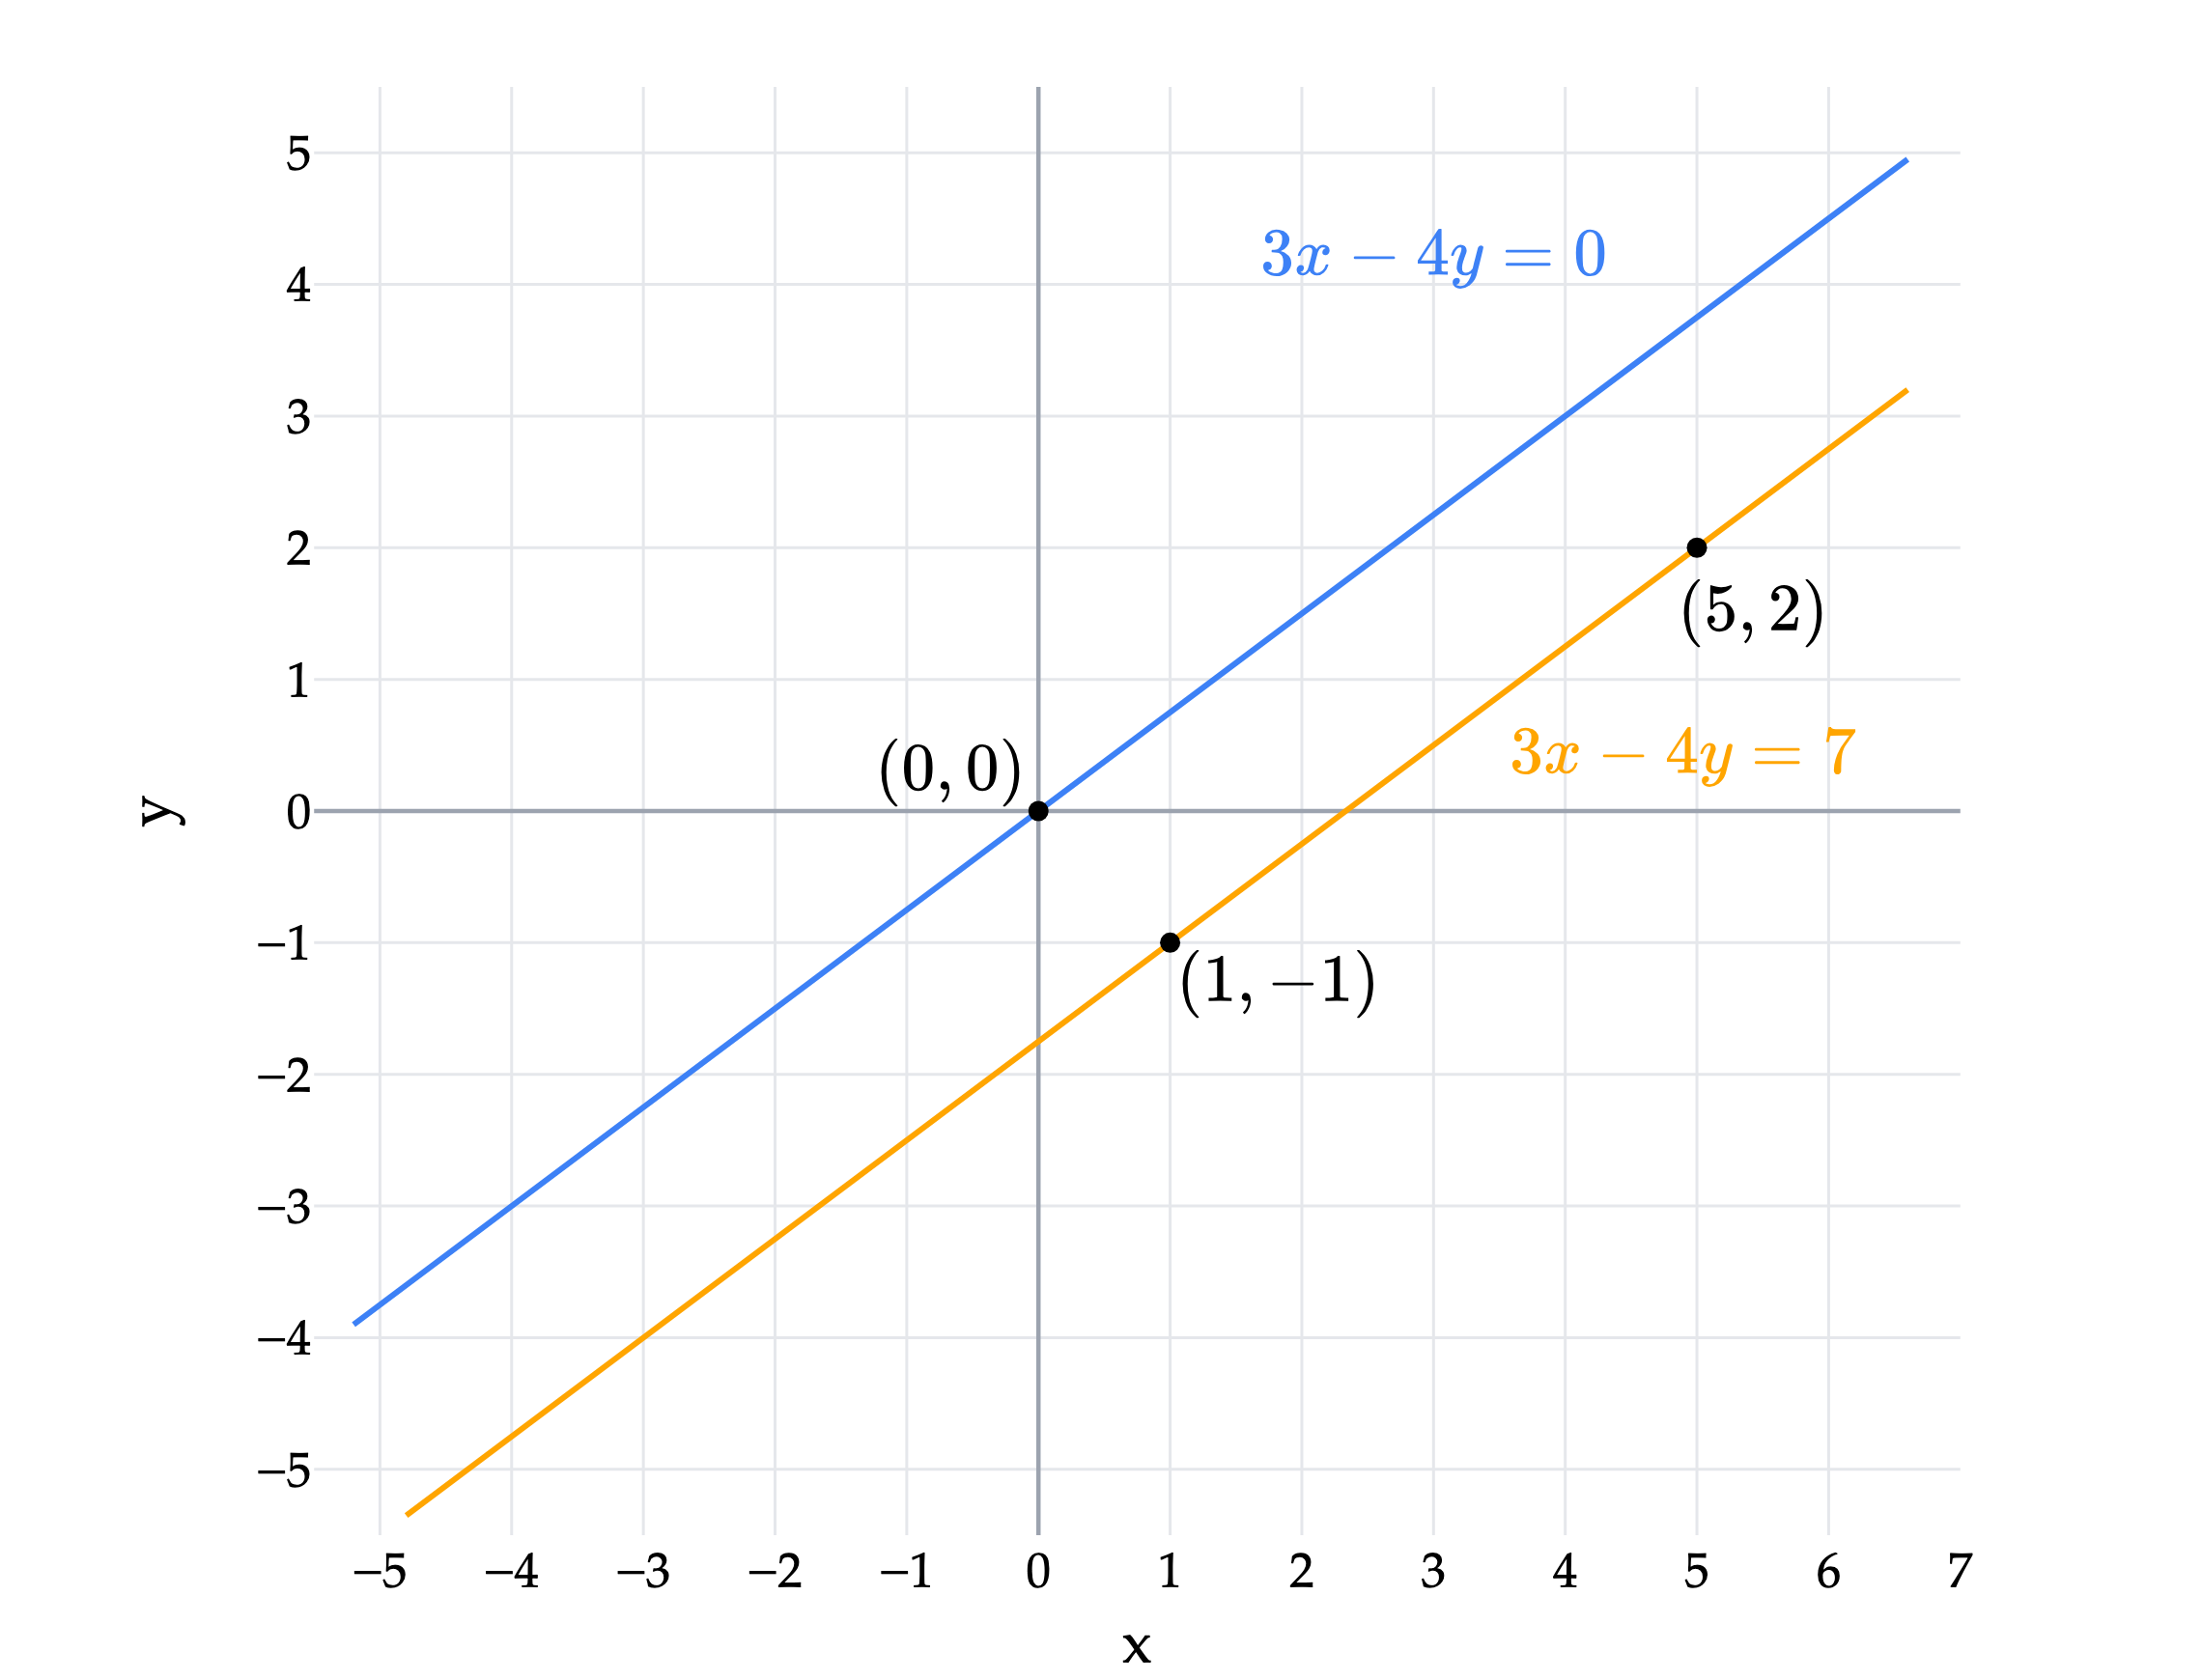

In [4]:
fig=base2((-5.5,7),(-5.5,5.5),width=760)
line2(fig,(-5.2,-3.9),(6.6,4.95))
line2(fig,(-4.8,-5.35),(6.6,3.2),ORANGE)
point2(fig,(0,0),'(0, 0)',dx=-0.7,dy=0.3)
point2(fig,(1,-1),'(1, -1)',dx=0.8,dy=-0.3)
point2(fig,(5,2),'(5, 2)',dx=0.4,dy=-0.5)
label2(fig,(3,4.2),r'$3x-4y=0$',color=BLUE)
label2(fig,(4.9,0.4),r'$3x-4y=7$',color=ORANGE)
fig.show(scale=3)

```{figure} #plot-21-parallel-lines
:label: fig-21-parallel-lines
:class: course-caption
:alt: Two parallel lines, only one of which passes through the origin.

The lines $3x-4y=0$ and $3x-4y=7$ are parallel.
```

:::{note} Definition: Homogeneous and nonhomogeneous linear equations
A linear equation $ax+by=0$ is **homogeneous**. If $a$ and $b$ are not both zero, its graph is a line through the origin.

An equation $ax+by=c$ with $c\ne0$ is **nonhomogeneous**. Its graph does not pass through the origin.
:::

Keeping $a$ and $b$ fixed while varying $c$ gives parallel lines. For example, $3x-4y=c$ describes every line parallel to $\ell$.

We'll first focus on the homogeneous case: lines through the origin.

---

## Lines as spans

The opening example suggests a second way to describe a line through the origin: take all scalar multiples of one nonzero vector along it.

For $\ell:3x-4y=0$, let's use

$$\vec v=\begin{bmatrix}4\\3\end{bmatrix}.$$

Every point on $\ell$ has the form $(4t,3t)$ for some scalar $t\in\mathbb R$. The figure below shows $\vec v$, $\frac12\vec v$, and $-\frac12\vec v$.

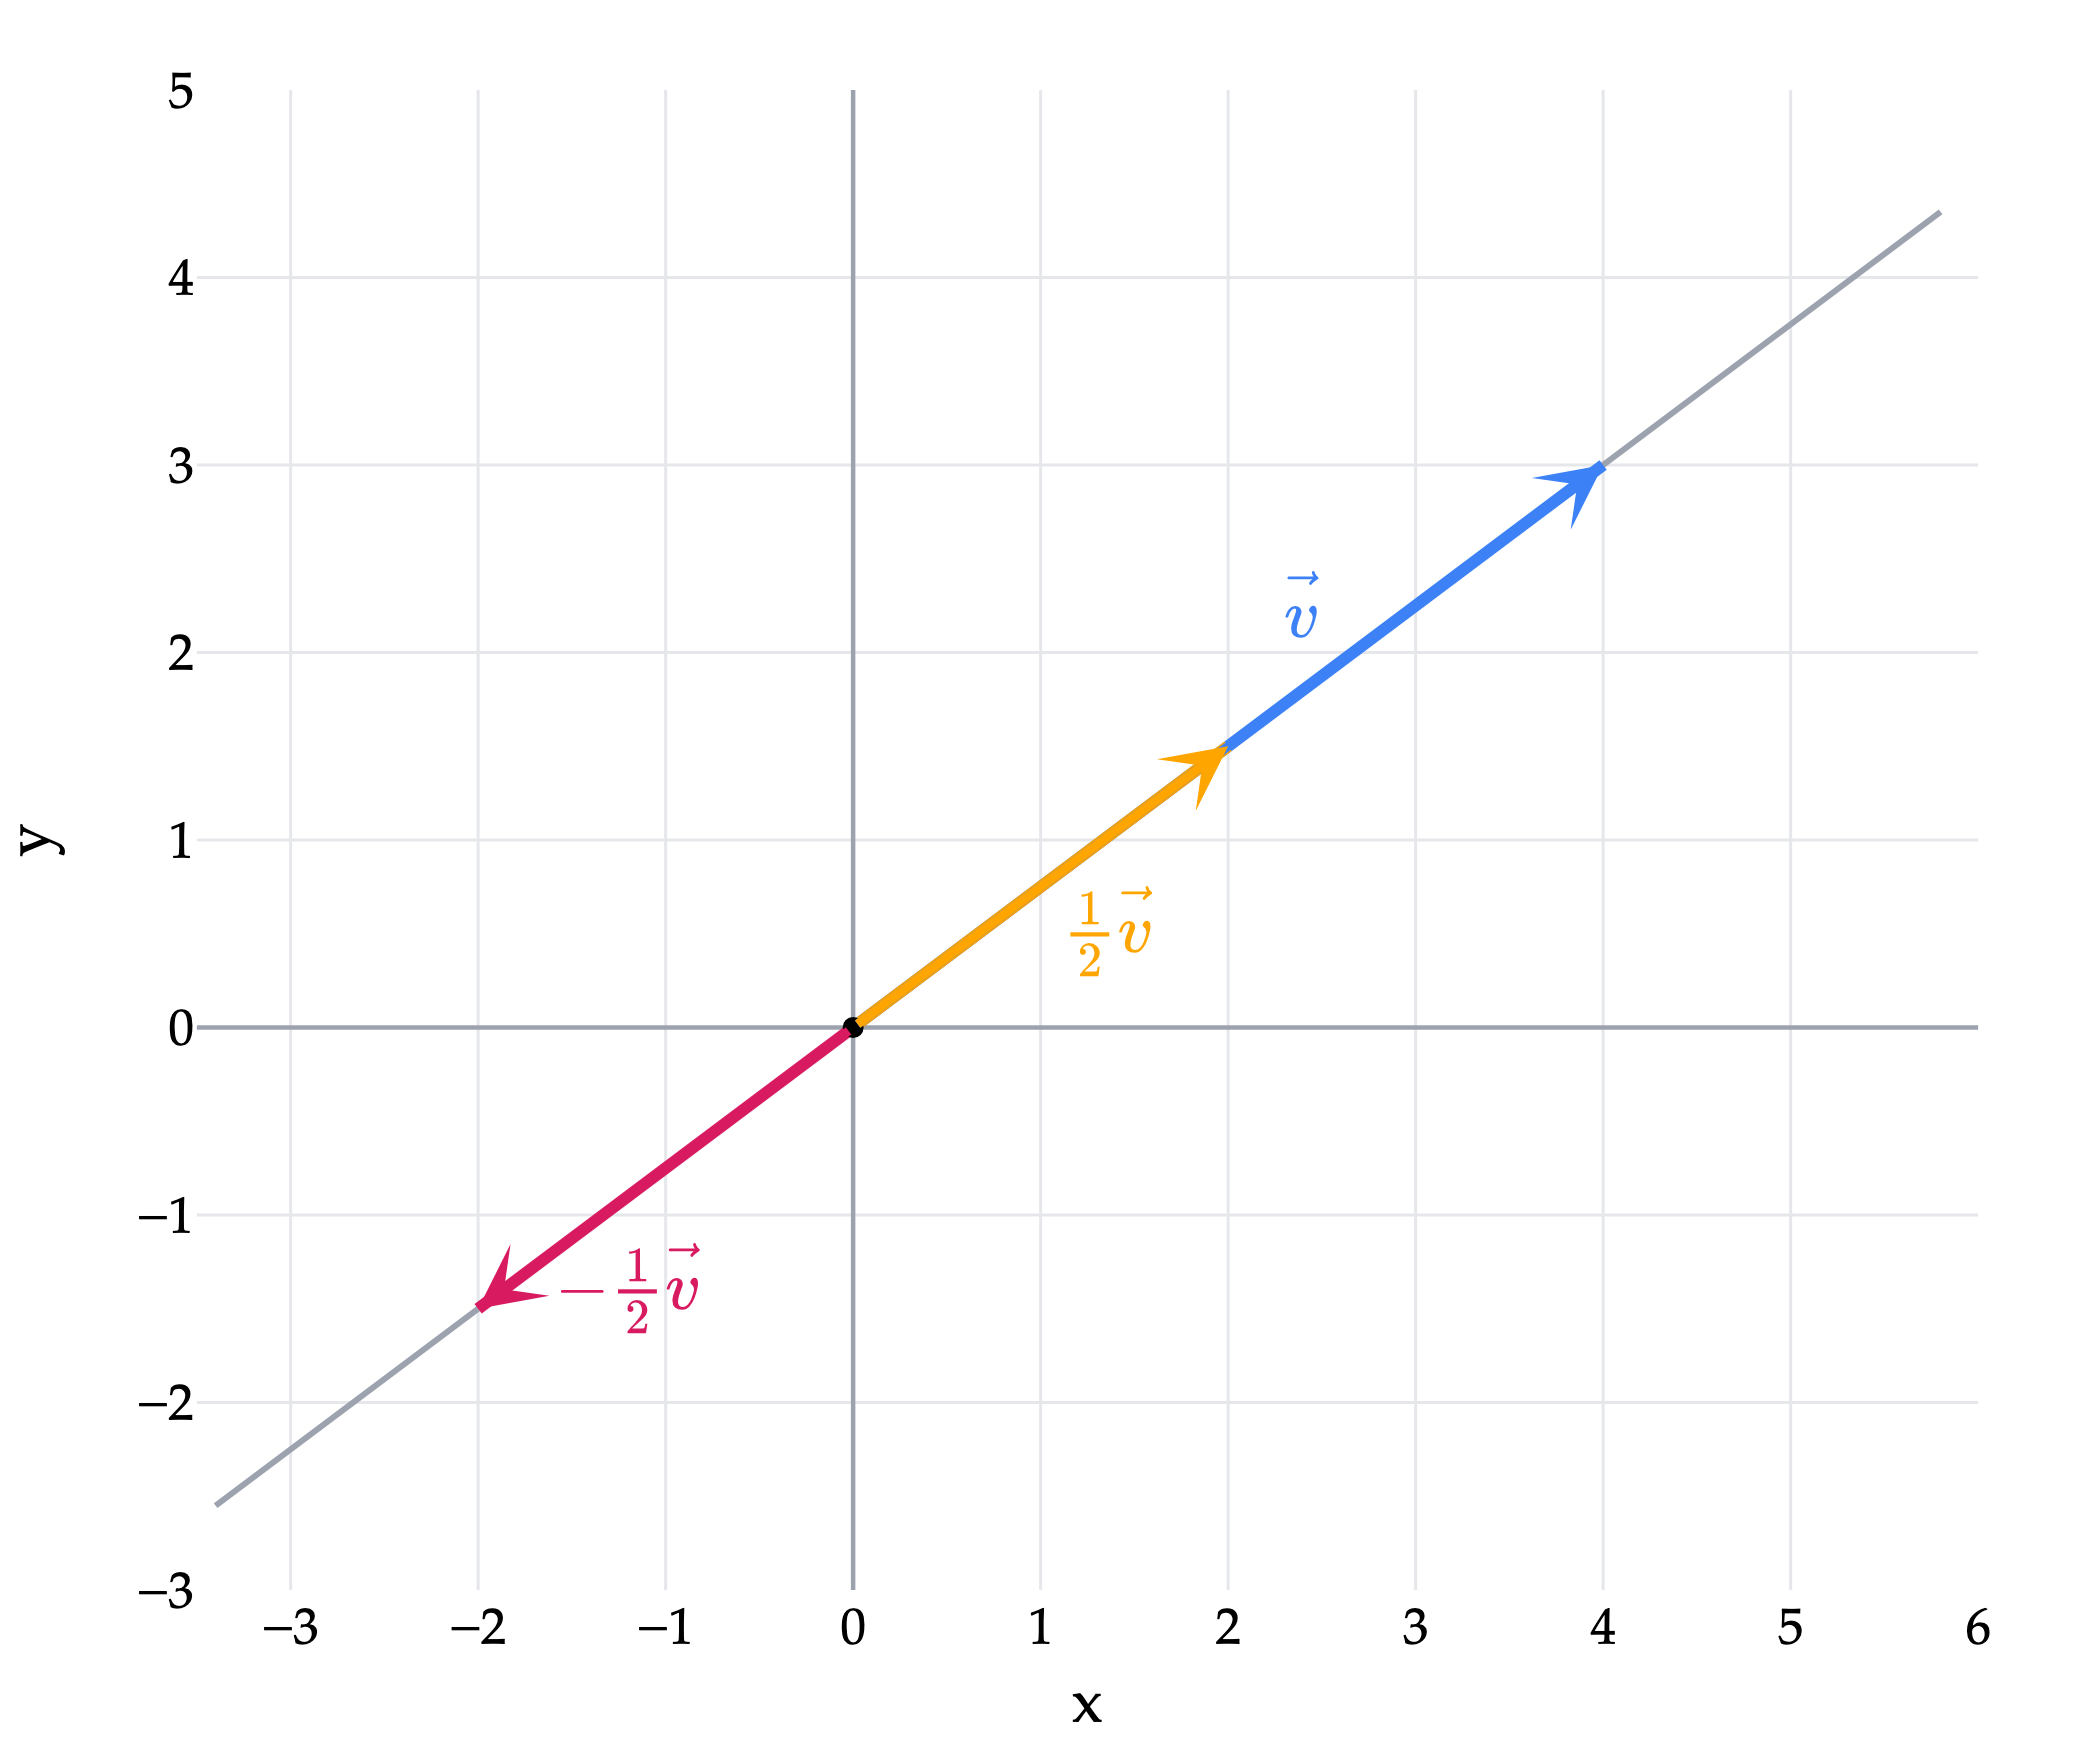

In [5]:
fig=base2((-3.5,6),(-3,5))
line2(fig,(-3.4,-2.55),(5.8,4.35),'#9ca3af')
vec2(fig,(4,3),r'$\vec{v}$',BLUE,dx=0.4,dy=0.8)
vec2(fig,(2,1.5),r'$\frac{1}{2}\vec{v}$',ORANGE,dx=0.35,dy=-0.2)
vec2(fig,(-2,-1.5),r'$-\frac{1}{2}\vec{v}$',PINK,dx=-0.2,dy=-0.6)
point2(fig,(0,0))
fig.show(scale=3)

```{figure} #plot-21-span
:label: fig-21-span
:class: course-caption
:alt: Three scalar multiples of the vector with components 4 and 3 along the line through the origin.

The vectors $\vec v=\begin{bmatrix}4\\3\end{bmatrix}$, $\frac12\vec v$, and $-\frac12\vec v$ lie on $\ell$.
```

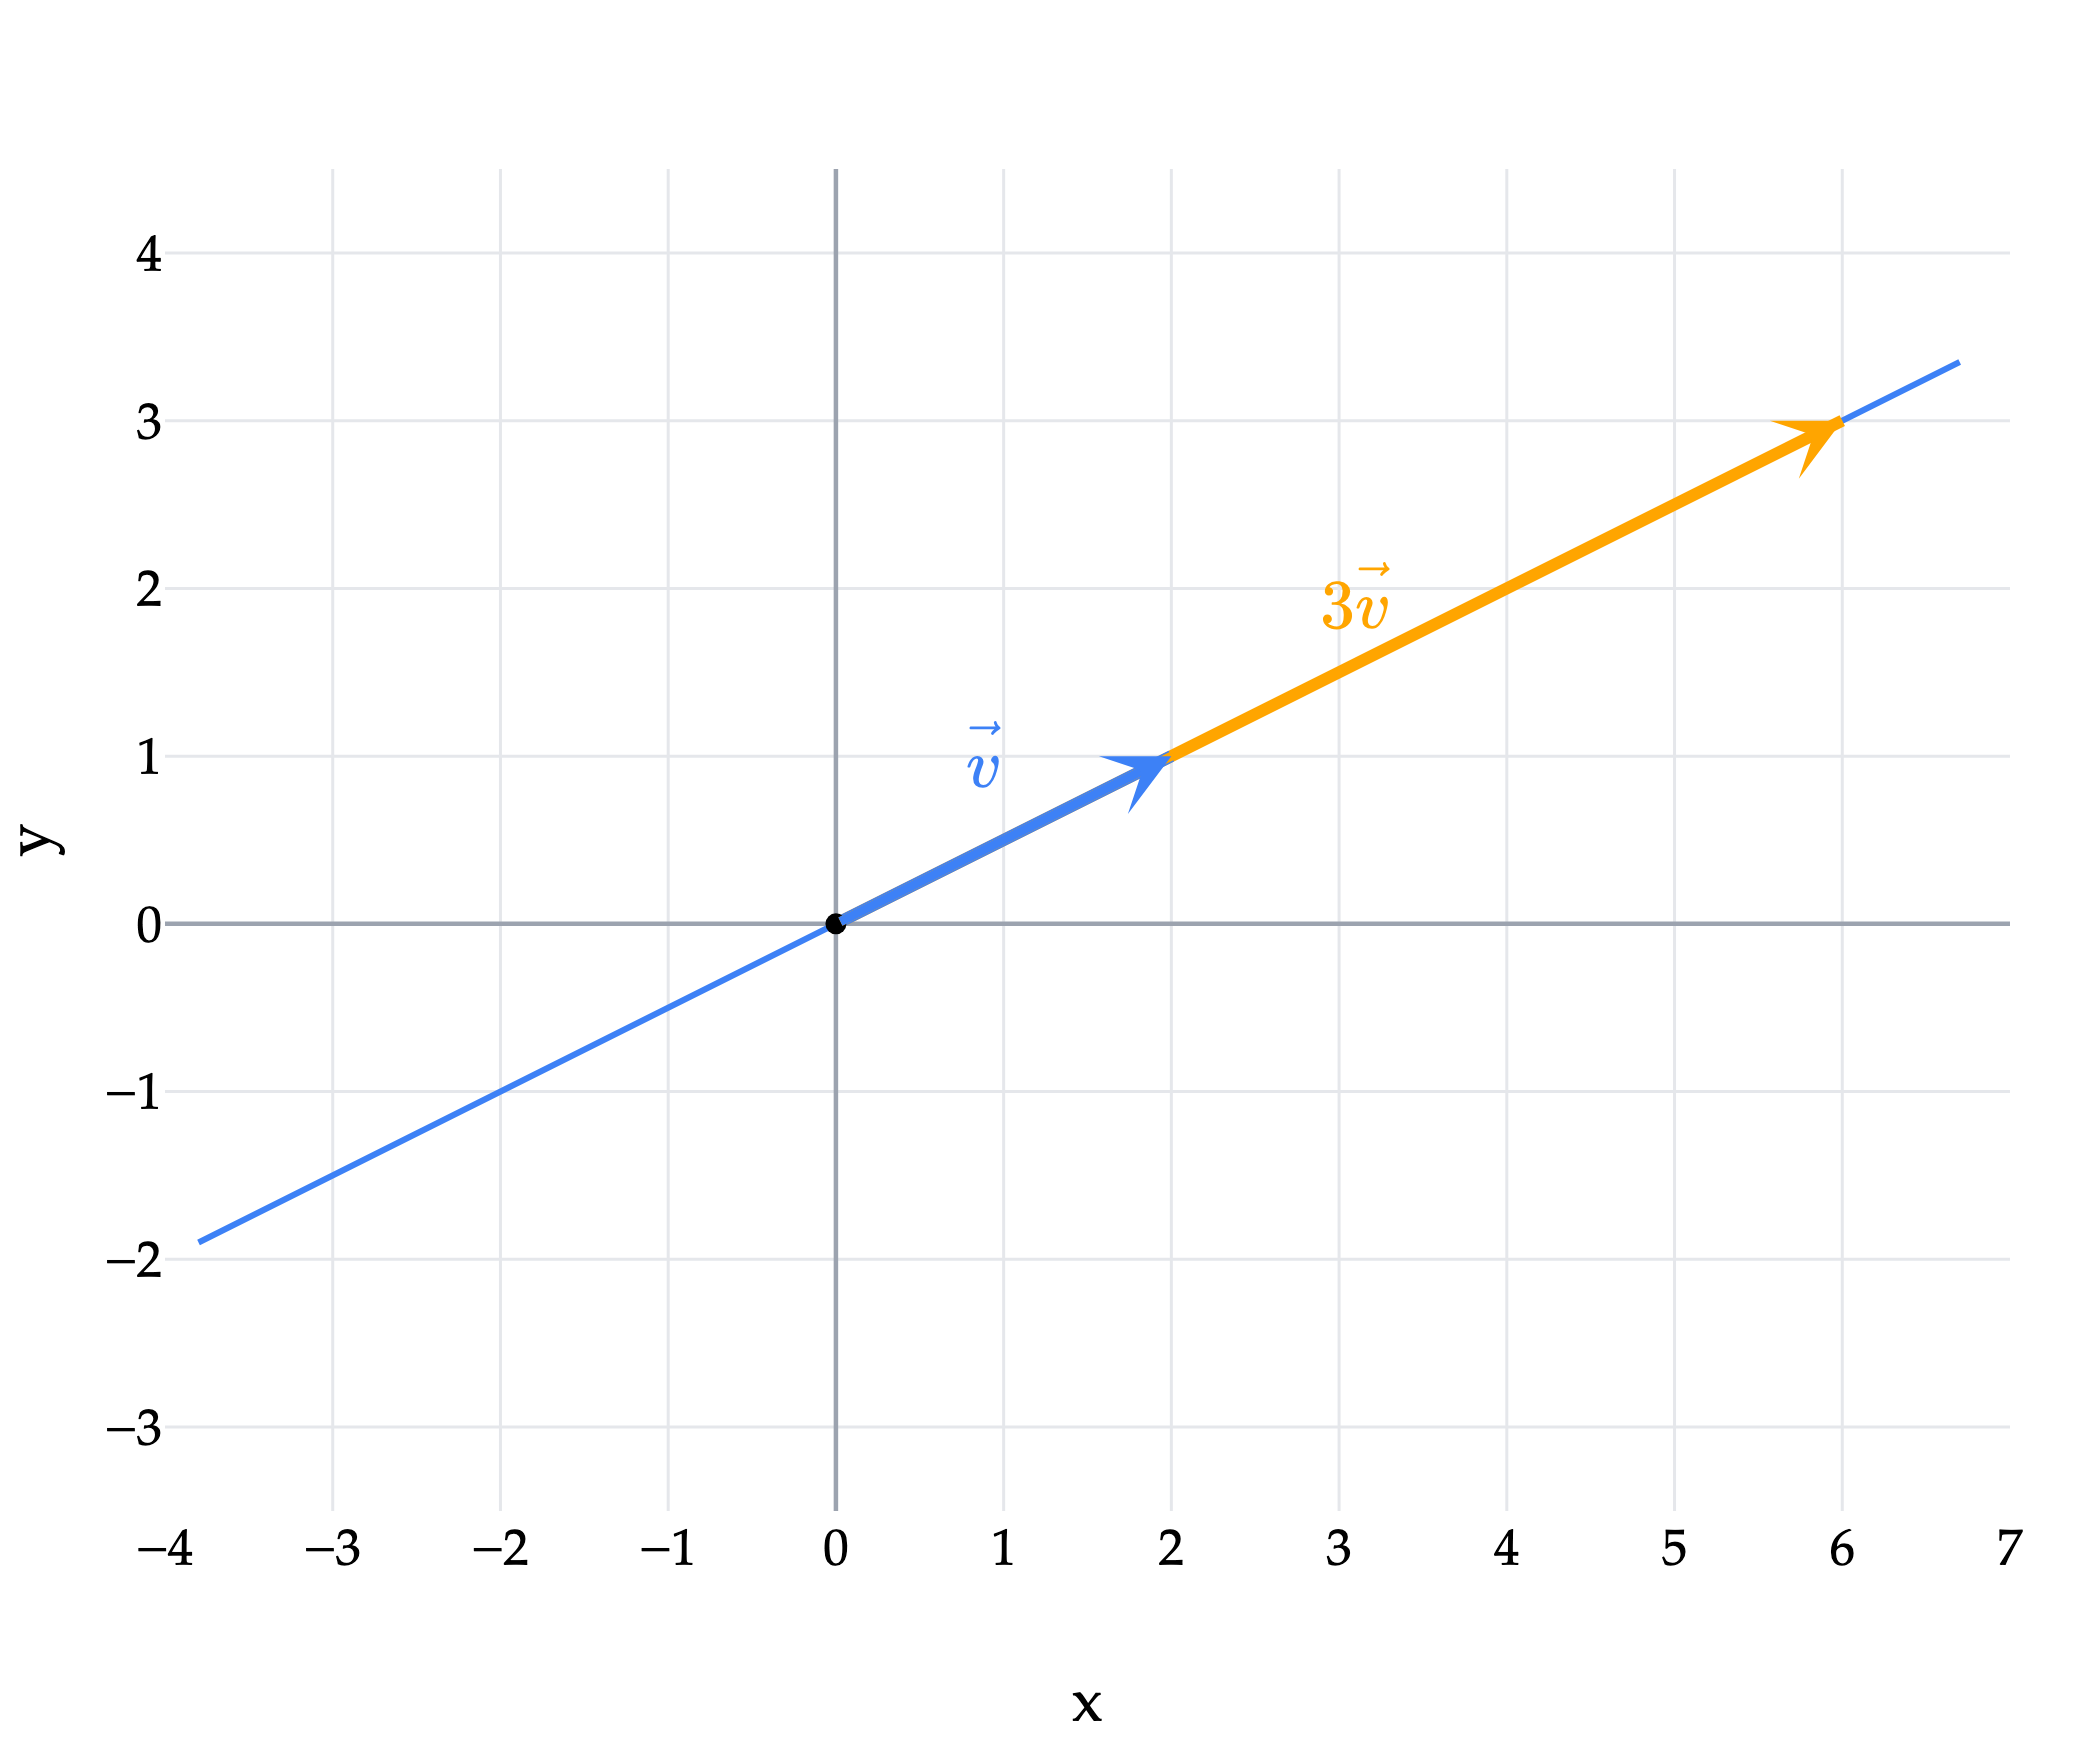

In [6]:
fig=base2((-4,7),(-3.5,4.5))
line2(fig,(-3.8,-1.9),(6.7,3.35))
vec2(fig,(6,3),r'$3\vec{v}$',ORANGE,dx=0.1,dy=0.5)
vec2(fig,(2,1),r'$\vec{v}$',BLUE,dx=-0.1,dy=0.55)
point2(fig,(0,0))
fig.show(scale=3)

:::{note} Definition: Span
The **span** of a vector $\vec v$ is the set of all its scalar multiples:

$$\operatorname{span}(\vec v)=\{t\vec v:t\in\mathbb R\}.$$

If $\vec v\ne\vec0$, its span is a line through the origin. The value $t=0$ gives the origin.
:::

So $\ell=\operatorname{span}(\vec v)$. We could have picked any nonzero vector along this line, such as

$$\frac12\vec v=\begin{bmatrix}2\\3/2\end{bmatrix},\qquad
-\frac12\vec v=\begin{bmatrix}-2\\-3/2\end{bmatrix},\qquad
\frac13\vec v=\begin{bmatrix}4/3\\1\end{bmatrix}.$$

Multiplying by a nonzero scalar changes the length, and possibly reverses the direction, as we saw in [Chapter 1.5](../ch01/01-05.ipynb). It does not change the line that the vector spans:

$$\ell=\operatorname{span}(\vec v)=\operatorname{span}\left(\frac12\vec v\right)
=\operatorname{span}\left(-\frac12\vec v\right)=\operatorname{span}\left(\frac13\vec v\right).$$

::::{tip} Activity 1

Let $\ell'$ be the span of

$$
\begin{bmatrix}
2\\
1
\end{bmatrix}.
$$

Draw $\ell'$. Give an equation describing $\ell'$.

:::{tip} Solution
:class: dropdown

The $y$-coordinate of any point on this line is half its $x$-coordinate. So one equation is $y-\frac12x=0$, or equivalently,

$$x-2y=0.$$

Multiplying by any nonzero number gives another equation for the same line. For example, $2x-4y=0$ works too, so the equation is not unique.

```{figure} #plot-21-activity-1
:label: fig-21-activity-1
:class: course-caption
:alt: The line of slope one half through the origin, with vectors v and 3v.

The line $\ell'$ contains $\vec v=\begin{bmatrix}2\\1\end{bmatrix}$ and $3\vec v=\begin{bmatrix}6\\3\end{bmatrix}$.
```
:::
::::

---

## Normal vectors and line equations

In [Chapter 1.6](../ch01/01-06.ipynb), we learned that two vectors are **orthogonal** exactly when their dot product is zero. We can use this fact to connect a line's equation to its geometry.

Let's return to $\ell:3x-4y=0$. We'll use $\ell^\perp$ to refer to the line through the origin perpendicular to $\ell$.

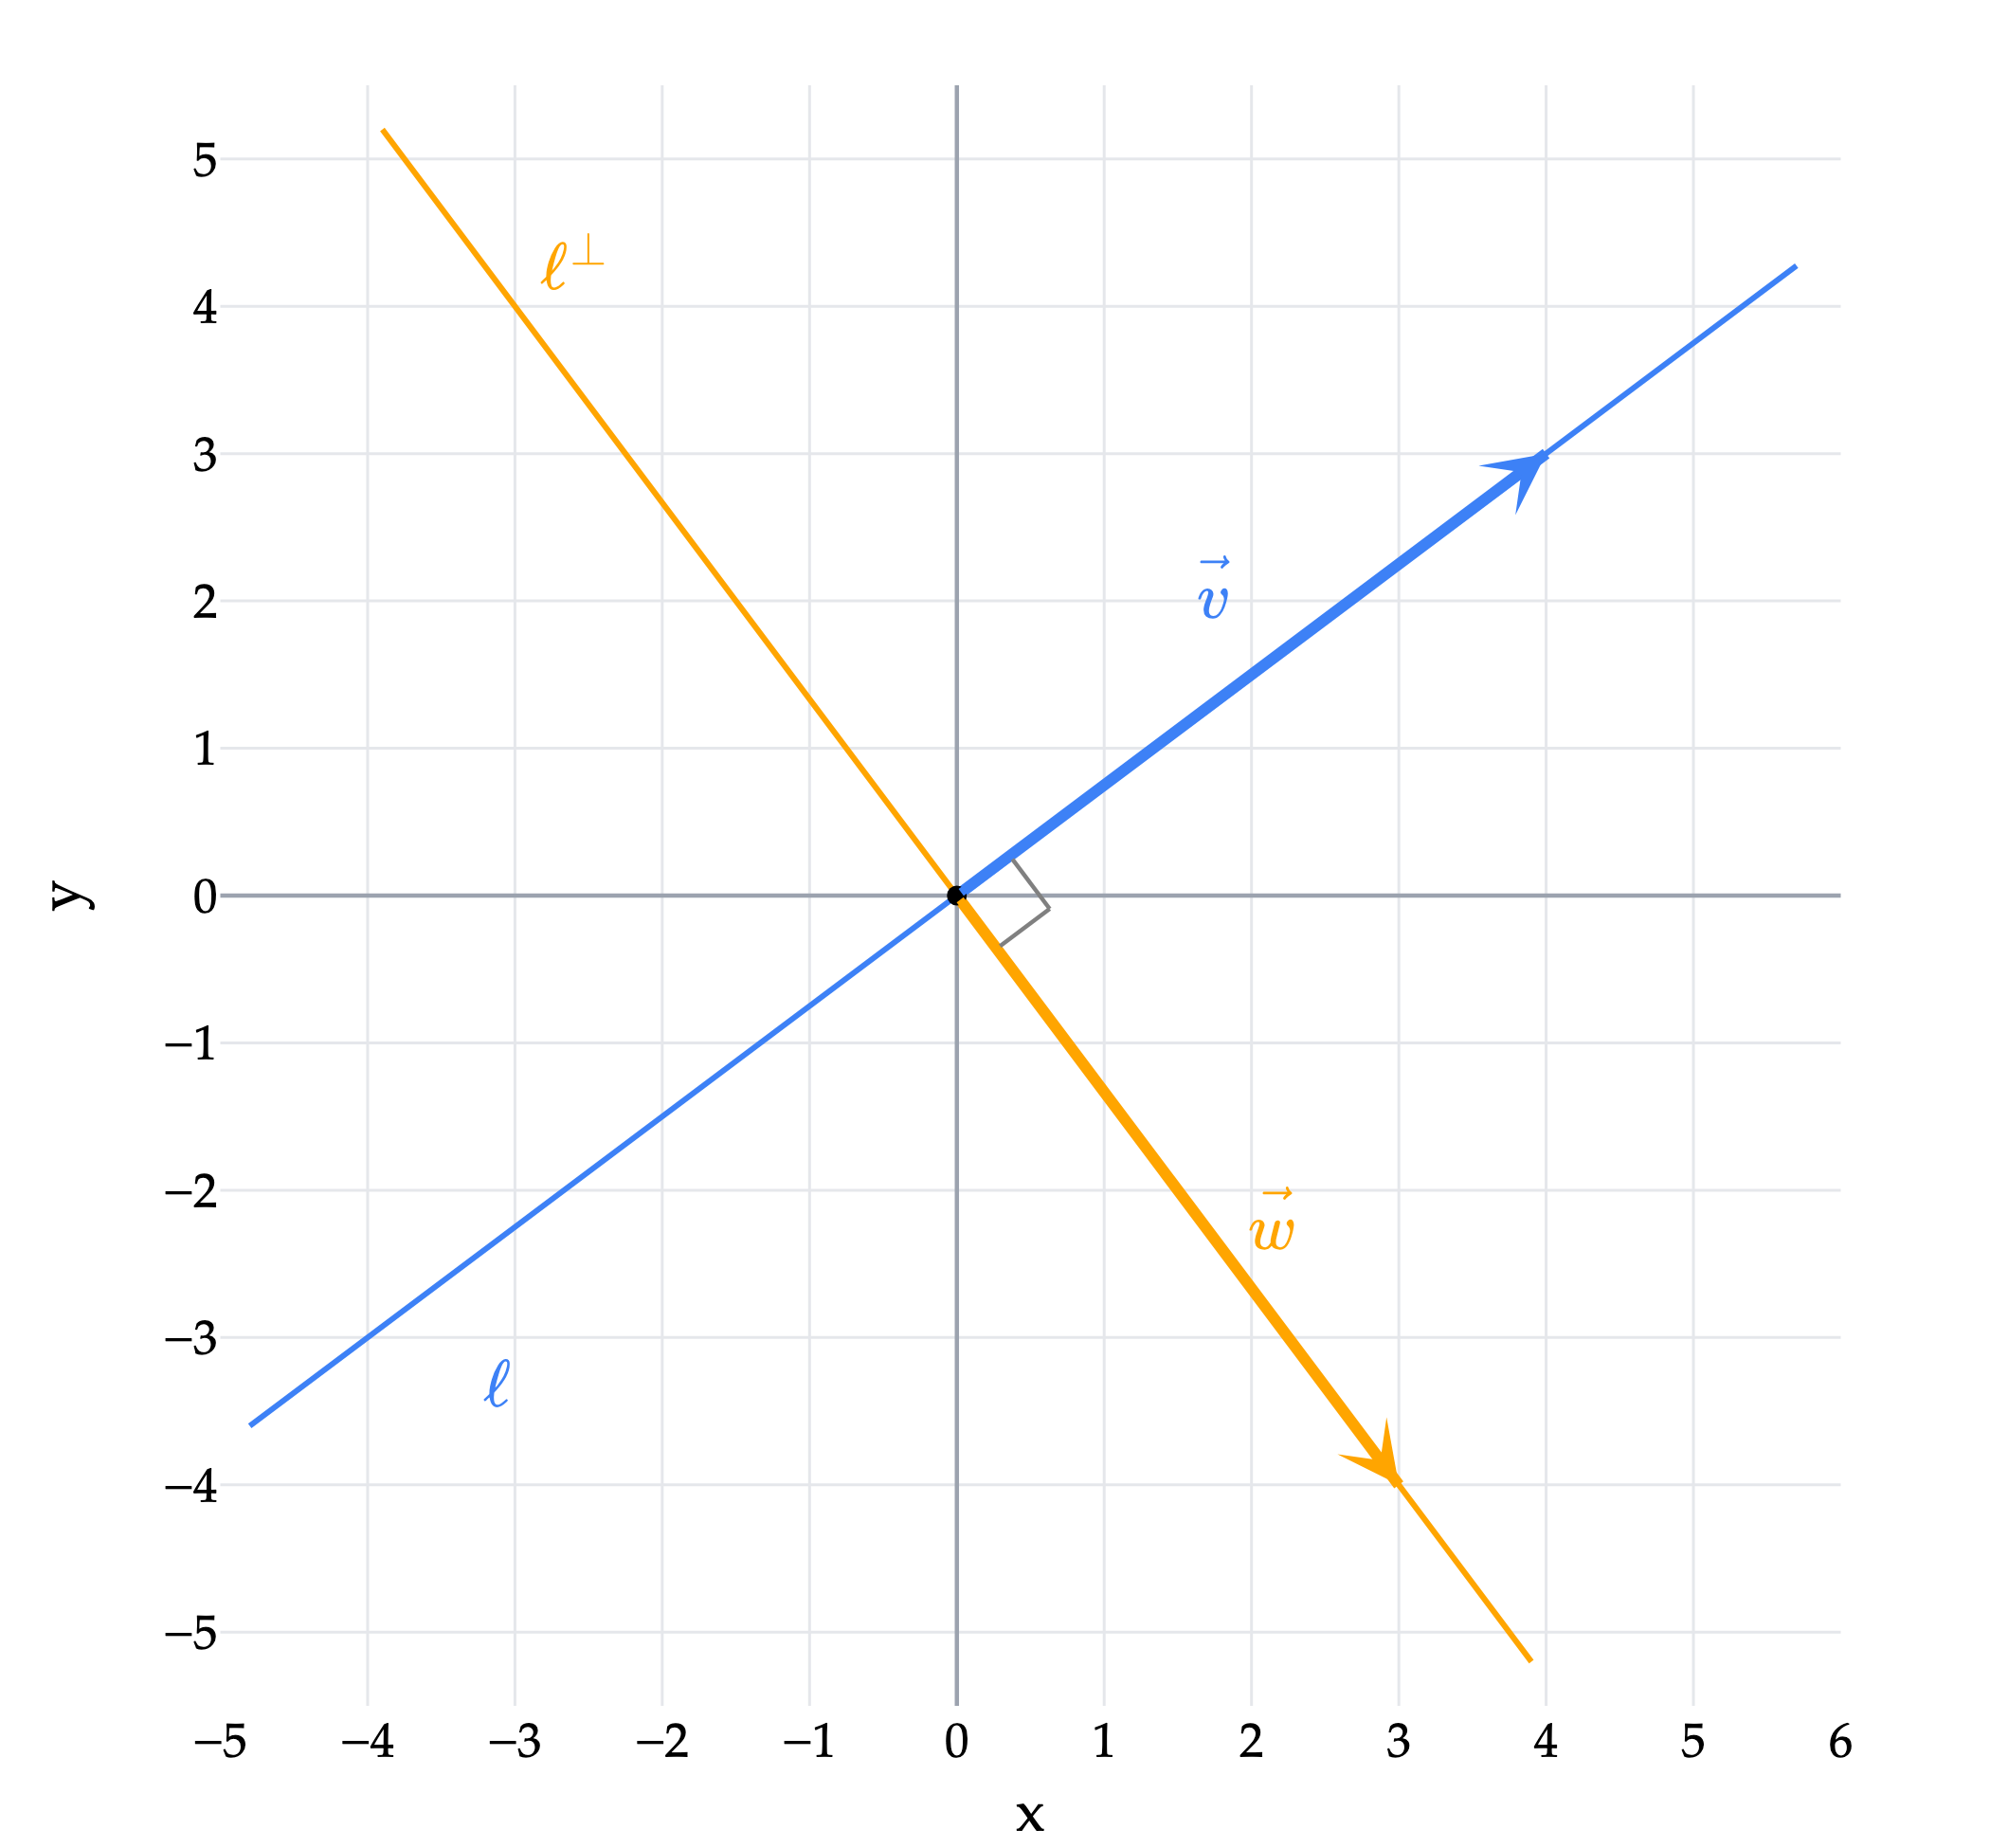

In [7]:
fig=base2((-5,6),(-5.5,5.5),height=650)
line2(fig,(-4.8,-3.6),(5.7,4.275),BLUE)
line2(fig,(-3.9,5.2),(3.9,-5.2),ORANGE)
vec2(fig,(4,3),r'$\vec{v}$',BLUE,dx=-0.25,dy=0.65)
vec2(fig,(3,-4),r'$\vec{w}$',ORANGE,dx=0.65,dy=-0.15)
square2(fig,(0,0),(4,3),(3,-4),0.45)
point2(fig,(0,0))
label2(fig,(-3.1,-3.3),r'$\ell$',color=BLUE)
label2(fig,(-2.6,4.3),r'$\ell^\perp$',color=ORANGE)
fig.show(scale=3)

```{figure} #plot-21-normal-vector
:label: fig-21-normal-vector
:class: course-caption
:alt: Perpendicular lines through the origin with a direction vector v and a normal vector w.

The normal vector $\vec w=\begin{bmatrix}3\\-4\end{bmatrix}$ is perpendicular to $\ell:3x-4y=0$.
```

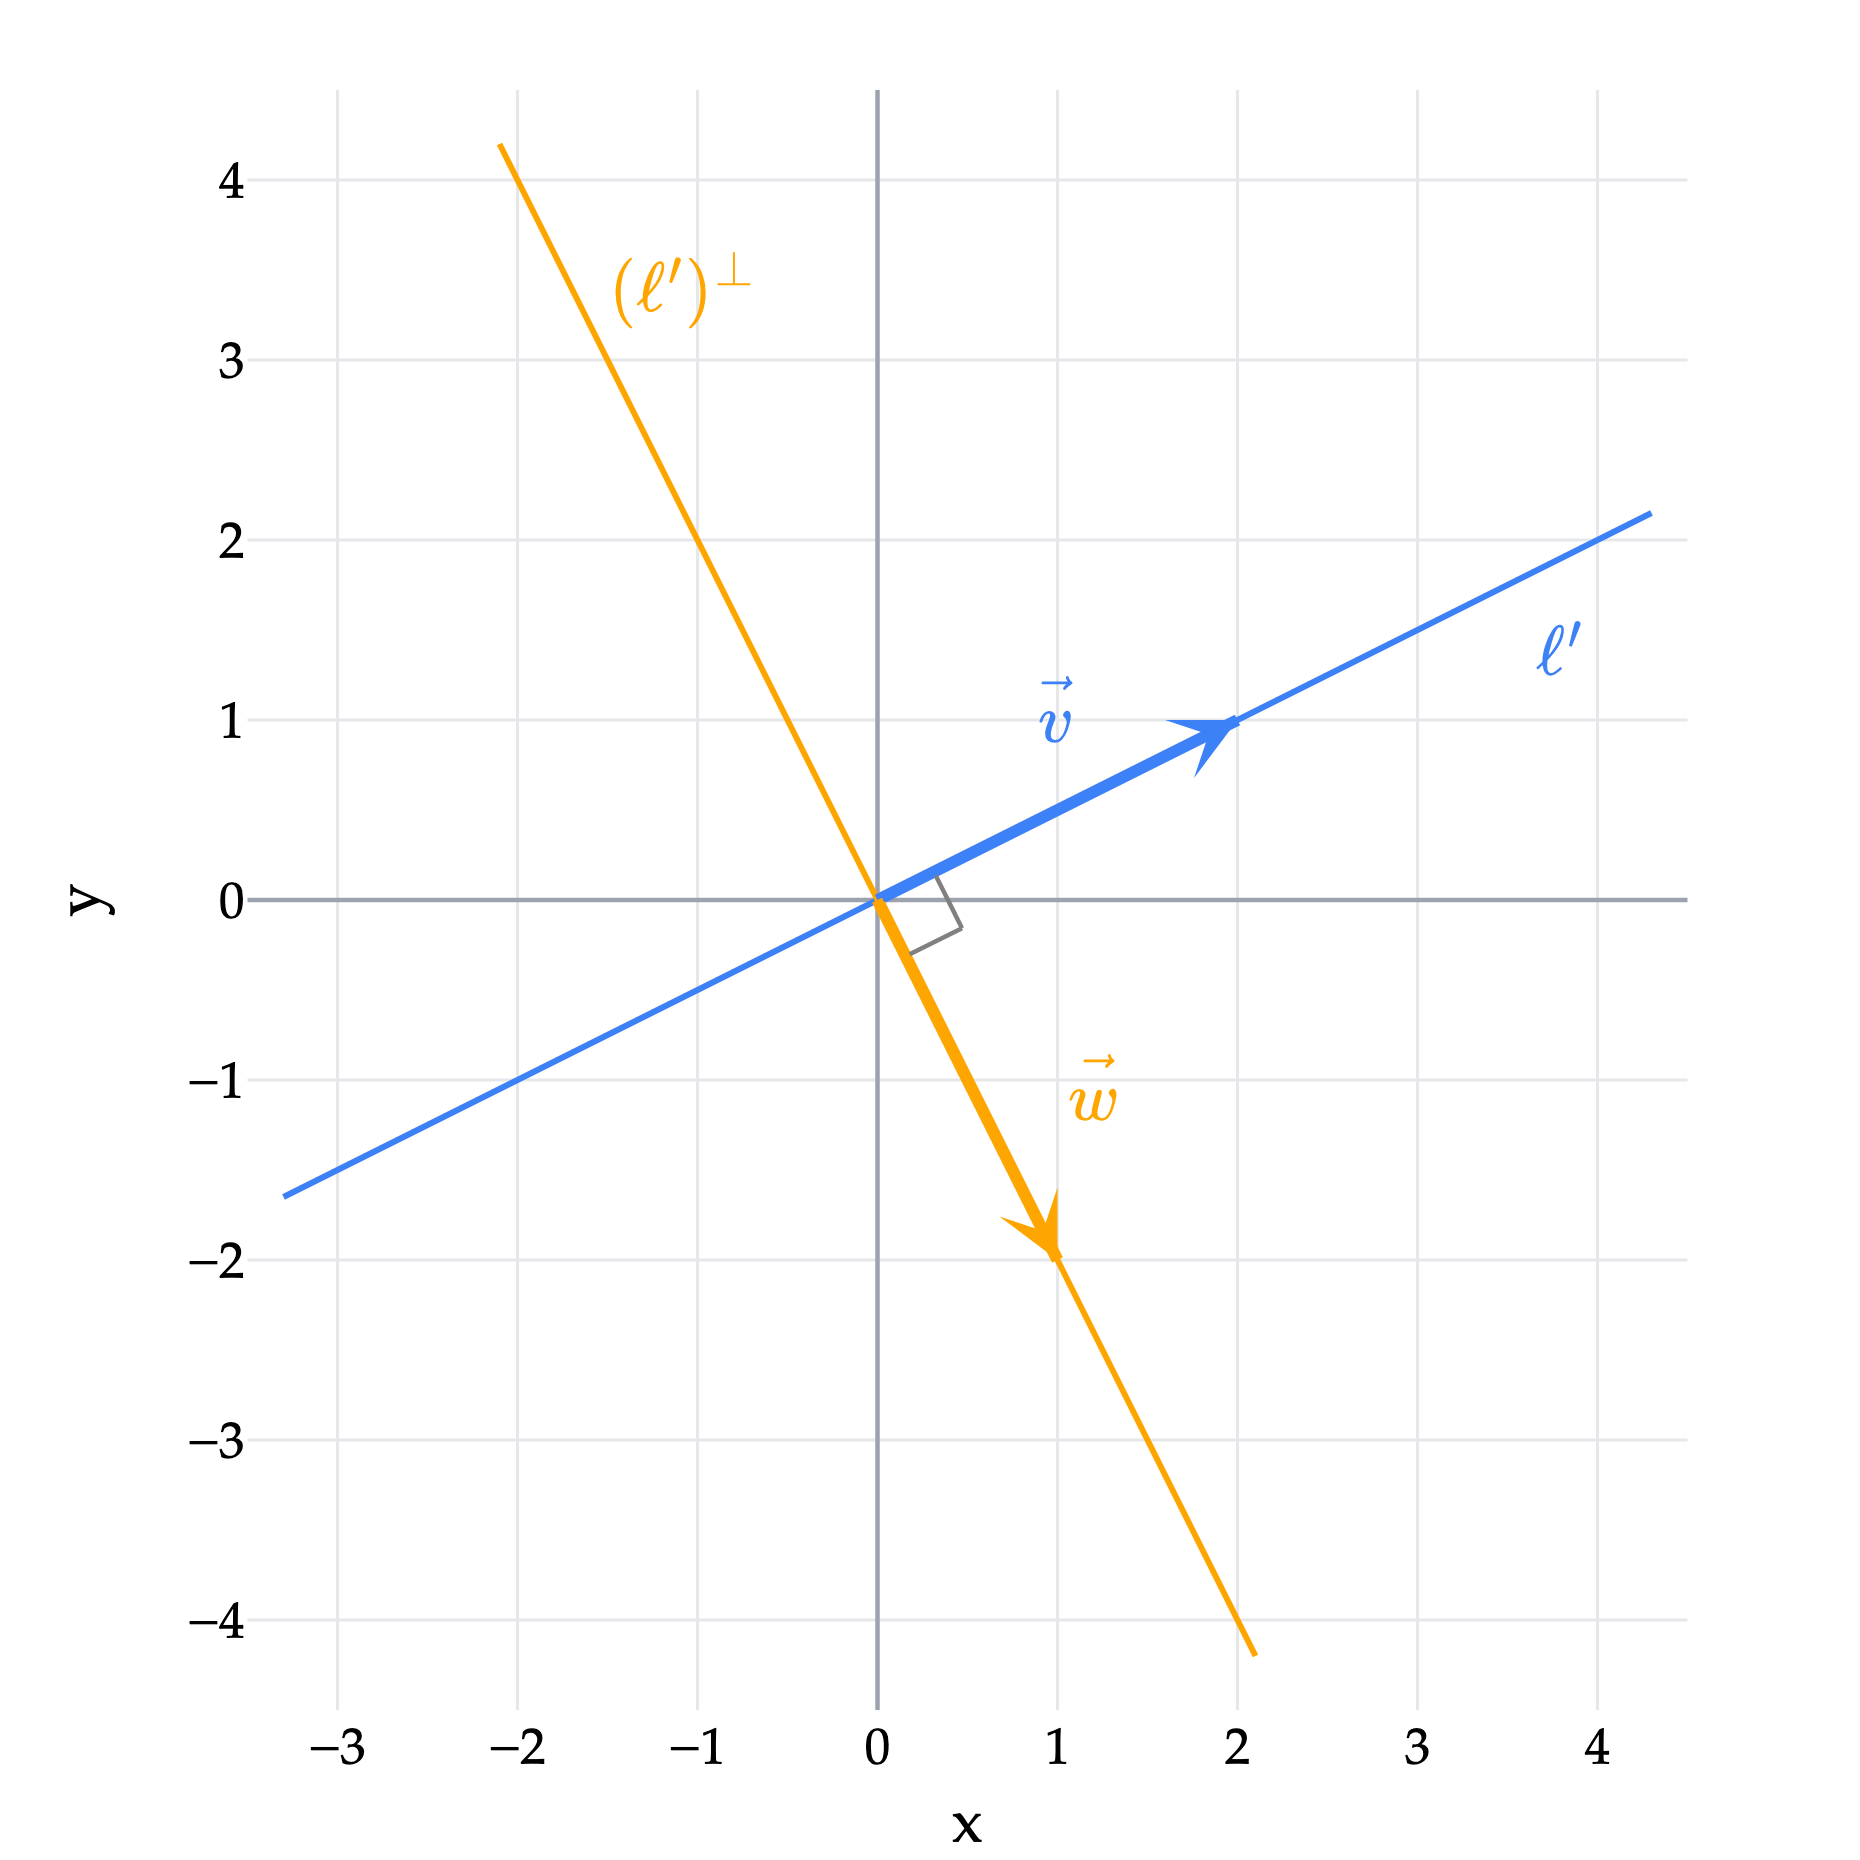

In [8]:
fig=base2((-3.5,4.5),(-4.5,4.5),width=620,height=620)
line2(fig,(-3.3,-1.65),(4.3,2.15),BLUE)
line2(fig,(-2.1,4.2),(2.1,-4.2),ORANGE)
vec2(fig,(2,1),r'$\vec{v}$',BLUE,dx=0,dy=0.6)
vec2(fig,(1,-2),r'$\vec{w}$',ORANGE,dx=0.7,dy=0)
square2(fig,(0,0),(2,1),(1,-2),0.35)
label2(fig,(3.8,1.4),r"$\ell'$",color=BLUE)
label2(fig,(-1.1,3.4),r"$(\ell')^\perp$",color=ORANGE)
fig.show(scale=3)

The coefficients of $3x-4y=0$ give us the vector

$$\vec w=\begin{bmatrix}3\\-4\end{bmatrix}.$$

Why does this vector lie on $\ell^\perp$? We can rewrite the equation of $\ell$ as a dot product:

$$\begin{bmatrix}3\\-4\end{bmatrix}\cdot\begin{bmatrix}x\\y\end{bmatrix}=0.$$

So $(x,y)$ lies on $\ell$ exactly when $\begin{bmatrix}x\\y\end{bmatrix}$ is orthogonal to $\vec w$.

:::{note} Definition: Normal vector
A **normal vector** to a line is a nonzero vector perpendicular to its direction.

For a line with equation $ax+by=c$, the coefficient vector $\begin{bmatrix}a\\b\end{bmatrix}$ is a normal vector.
:::

We now have two ways to describe $\ell$: take multiples of a vector along it, or use a vector perpendicular to it. With $\vec v=\begin{bmatrix}4\\3\end{bmatrix}$ and $\vec w=\begin{bmatrix}3\\-4\end{bmatrix}$,

$$\ell=\operatorname{span}(\vec v)
=\left\{\begin{bmatrix}x\\y\end{bmatrix}:\vec w\cdot\begin{bmatrix}x\\y\end{bmatrix}=0\right\}.$$

The roles reverse for $\ell^\perp$: $\vec w$ lies along it, and $\vec v$ is perpendicular to it. Therefore,

$$\ell^\perp=\operatorname{span}(\vec w)
=\left\{\begin{bmatrix}x\\y\end{bmatrix}:\vec v\cdot\begin{bmatrix}x\\y\end{bmatrix}=0\right\}.$$

Taking the dot product with $\vec v$ gives the equation $4x+3y=0$ for $\ell^\perp$.

A normal vector is not unique. For example, $3\vec w=\begin{bmatrix}9\\-12\end{bmatrix}$ is also normal to $\ell$, giving $9x-12y=0$. This is just the original equation multiplied by $3$, so it describes the same line.

::::{tip} Activity 2

Consider the line

$$\ell'=\operatorname{span}\left(\begin{bmatrix}2\\1\end{bmatrix}\right).$$

1. Draw $\ell'$ and $(\ell')^\perp$.
1. Find a nonzero vector on $(\ell')^\perp$.
1. Use your vector from the previous subpart to write an equation for $\ell'$.
1. Find another nonzero vector on $(\ell')^\perp$.
1. Use your vector from the previous subpart to write another equation for $\ell'$.
1. How do your equations for $\ell'$ differ?
1. Write down an equation for $(\ell')^\perp$.

:::{tip} Solution
:class: dropdown

1. The line $\ell'$ has slope $1/2$, and $(\ell')^\perp$ has slope $-2$. Both pass through the origin, as shown below.
2. One choice is $\vec w=\begin{bmatrix}1\\-2\end{bmatrix}$, since $\begin{bmatrix}2\\1\end{bmatrix}\cdot\begin{bmatrix}1\\-2\end{bmatrix}=2-2=0$.
3. Using $\vec w$ as a normal vector gives $x-2y=0$.
4. Another choice is $2\vec w=\begin{bmatrix}2\\-4\end{bmatrix}$.
5. This gives $2x-4y=0$.
6. The second equation is twice the first, so they have the same solution set.
7. The vector $\begin{bmatrix}2\\1\end{bmatrix}$ is normal to $(\ell')^\perp$, giving $2x+y=0$.
```{figure} #plot-21-activity-2
:label: fig-21-activity-2
:class: course-caption
:alt: A line of slope one half and its perpendicular line of slope negative two, both through the origin.

The lines $\ell'$ and $(\ell')^\perp$, with $\vec v=\begin{bmatrix}2\\1\end{bmatrix}$ and $\vec w=\begin{bmatrix}1\\-2\end{bmatrix}$.
```
:::
::::

---

## Affine lines

Now let's return to $3x-4y=7$, which does not pass through the origin.

In [Chapter 1.4](../ch01/01-04.ipynb), we saw that a vector represents a displacement and can be drawn from any starting point. We can use that idea to shift an entire line.

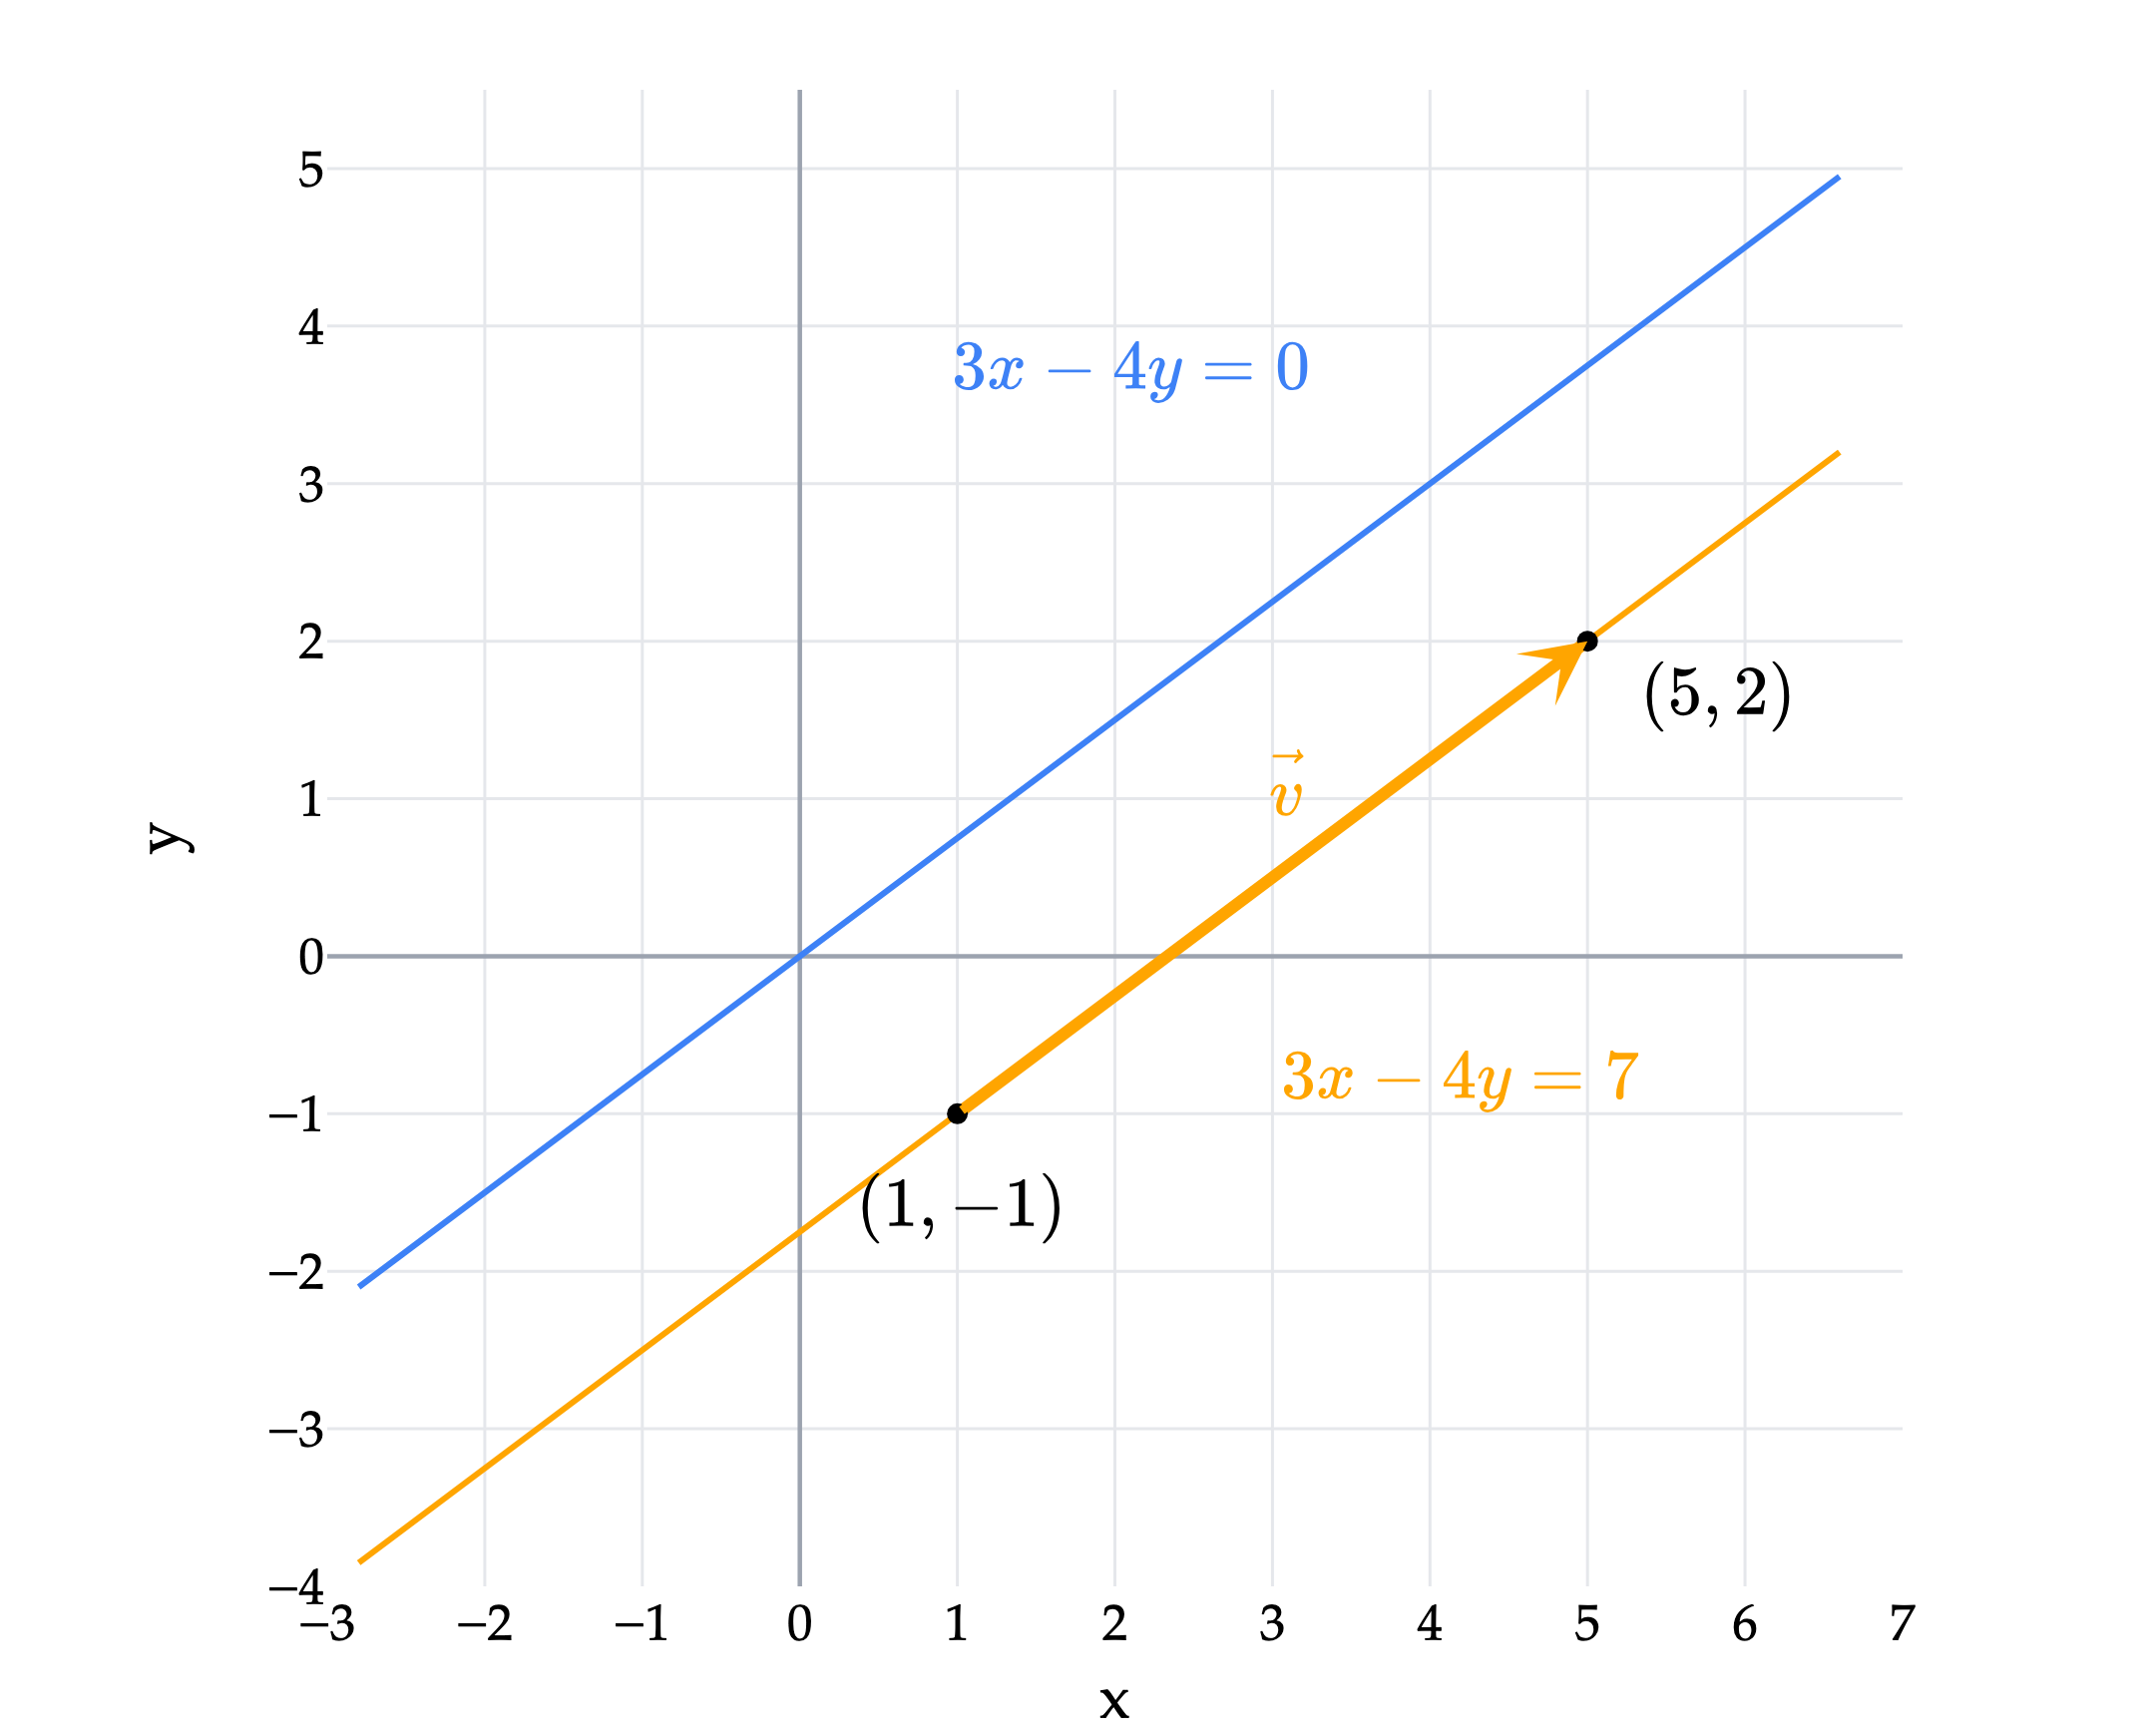

In [9]:
fig=base2((-3,7),(-4,5.5),width=720)
line2(fig,(-2.8,-2.1),(6.6,4.95),BLUE)
line2(fig,(-2.8,-3.85),(6.6,3.2),ORANGE)
vec2(fig,(5,2),r'$\vec{v}$',ORANGE,start=(1,-1),dx=0.1,dy=0.65)
point2(fig,(1,-1),'(1, -1)',dx=0,dy=-0.6)
point2(fig,(5,2),'(5, 2)',dx=0.8,dy=-0.35)
label2(fig,(2.1,3.7),r'$3x-4y=0$',color=BLUE)
label2(fig,(4.2,-0.8),r'$3x-4y=7$',color=ORANGE)
fig.show(scale=3)

```{figure} #plot-21-affine-line
:label: fig-21-affine-line
:class: course-caption
:alt: An arrow from (1, -1) to (5, 2) on the shifted line 3x minus 4y equals 7.

Starting at $(1,-1)$ and adding $\vec v=\begin{bmatrix}4\\3\end{bmatrix}$ takes us to $(5,2)$.
```

The point $(1,-1)$ lies on $3x-4y=7$. Starting there and adding any multiple of $\vec v=\begin{bmatrix}4\\3\end{bmatrix}$ takes us to another point on the line. The vector $\vec v$ gives its direction, just as it did for $3x-4y=0$.

So we can describe the line as

$$\begin{bmatrix}1\\-1\end{bmatrix}+\operatorname{span}(\vec v)
=\left\{\begin{bmatrix}1\\-1\end{bmatrix}+t\vec v:t\in\mathbb R\right\}.$$

Our starting point is not unique. For example, $(5,2)$ also lies on the line, so the same line is

$$\left\{\begin{bmatrix}5\\2\end{bmatrix}+t\vec v:t\in\mathbb R\right\}.$$

:::{note} Definition: Affine line
An **affine line** is a translation of the span of a nonzero vector. It has the form

$$\vec p+\operatorname{span}(\vec v)=\{\vec p+t\vec v:t\in\mathbb R\},\qquad\vec v\ne\vec0.$$

The fixed vector $\vec p$ gives a starting point, and $\vec v$ gives the direction. An affine line need not pass through the origin.
:::

::::{tip} Activity 3

Can you describe affine lines using a normal vector and a dot product?

:::{tip} Solution
:class: dropdown

Yes. If $\vec w=\begin{bmatrix}a\\b\end{bmatrix}$ is a nonzero normal vector, the line $ax+by=c$ consists of all $(x,y)$ satisfying

$$\vec w\cdot\begin{bmatrix}x\\y\end{bmatrix}=c.$$

For example, $3x-4y=7$ can be written as

$$\begin{bmatrix}3\\-4\end{bmatrix}\cdot\begin{bmatrix}x\\y\end{bmatrix}=7.$$

The dot product with the fixed normal vector is the same constant at every point on the line.
:::
::::